In [1]:
# ============================================================================
# Cross-Species Fruit Quality Grading via Few-Shot Prototypical Networks
# 
# Author: Amr Samir
# Master's Thesis - 2026
# ============================================================================
# 
# RESEARCH GAP: 
# While models can classify fruit species, they fail to generalize quality 
# grading (Good/Bad) across unseen fruit types. This work proves that metric 
# learning can learn "defectness" rather than "fruit-specific features."
#
# KEY CONTRIBUTION:
# Train on {Apple, Banana, Grape} → Test on {Mango, Orange} WITHOUT retraining
# ============================================================================

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.5.1


In [3]:
# ============================================================================
# CONFIGURATION - Modify these based on your dataset and experiments
# ============================================================================

class Config:
    """Centralized configuration for all experiments"""
    
    DATA_ROOT = r"C:\Users\admin\Desktop\Amr Samir\FruitVision"
    
    TRAIN_FRUITS = ['apple', 'banana', 'grape']
    TEST_FRUITS = ['mango', 'orange']
    
    CLASSES = ['fresh', 'rotten']
    N_CLASSES = 2
    
    N_SHOT = 5       
    N_QUERY = 15     
    N_EPISODES_TRAIN = 500    
    N_EPISODES_VAL = 200      
    N_EPISODES_TEST = 600     
    
    BACKBONE = 'resnet18'     
    EMBEDDING_DIM = 256       
    PRETRAINED = True         
    
    EPOCHS = 30               
    LEARNING_RATE = 5e-5      
    WEIGHT_DECAY = 5e-4       
    BATCH_SIZE = 1            
    
    DROPOUT_RATE = 0.4        
    LABEL_SMOOTHING = 0.1    
    GRADIENT_CLIP = 1.0       
    EARLY_STOPPING_PATIENCE = 7  
    CONTRASTIVE_WEIGHT = 0.1  
    TEMPERATURE = 0.5         
    
    WARMUP_EPOCHS = 3         # Warmup epochs before full LR
    
    VAL_SPLIT_RATIO = 0.15    # 15% of training images for validation
    
    IMAGE_SIZE = 224
    RESIZE_SIZE = 256         # Resize before random crop
    
    CHECKPOINT_DIR = './checkpoints'
    RESULTS_DIR = './results'
    THESIS_FIGS_DIR = r"C:/Users/admin/Desktop/Amr Samir/Final"
    
    EXPERIMENT_NAME = f"ProtoNet_{BACKBONE}_{N_SHOT}shot"
    
    ABLATION_SHOTS = [1, 3, 5, 10]  # For N-shot ablation study
    ABLATION_EPISODES = 300         # Episodes per ablation experiment

config = Config()

# Create directories
os.makedirs(config.CHECKPOINT_DIR, exist_ok=True)
os.makedirs(config.RESULTS_DIR, exist_ok=True)
os.makedirs(config.THESIS_FIGS_DIR, exist_ok=True)

print("=" * 60)
print("EXPERIMENTAL CONFIGURATION")
print("=" * 60)
print(f"Train Fruits (SEEN):     {config.TRAIN_FRUITS}")
print(f"Test Fruits (UNSEEN):    {config.TEST_FRUITS}")
print(f"Few-Shot Setting:        {config.N_SHOT}-shot, {config.N_QUERY}-query")
print(f"Backbone:                {config.BACKBONE}")
print(f"Embedding Dimension:     {config.EMBEDDING_DIM}")
print(f"Training Episodes/Epoch: {config.N_EPISODES_TRAIN}")
print(f"Learning Rate:           {config.LEARNING_RATE}")
print(f"Regularization:          Dropout={config.DROPOUT_RATE}, L2={config.WEIGHT_DECAY}")
print(f"Validation Split:        {config.VAL_SPLIT_RATIO*100:.0f}% held out")
print(f"Early Stopping:          Patience={config.EARLY_STOPPING_PATIENCE}")
print("=" * 60)

EXPERIMENTAL CONFIGURATION
Train Fruits (SEEN):     ['apple', 'banana', 'grape']
Test Fruits (UNSEEN):    ['mango', 'orange']
Few-Shot Setting:        5-shot, 15-query
Backbone:                resnet18
Embedding Dimension:     256
Training Episodes/Epoch: 500
Learning Rate:           5e-05
Regularization:          Dropout=0.4, L2=0.0005
Validation Split:        15% held out
Early Stopping:          Patience=7


## 2. Data Augmentation & Transforms

Strong augmentation is critical for learning generalizable defect features. We use different transforms for support (stable) and query (augmented) sets.

In [4]:
# ============================================================================
# DATA AUGMENTATION STRATEGIES - BALANCED FOR AVOIDING OVERFITTING
# ============================================================================

# Training augmentation (balanced - not too aggressive)
train_transform = transforms.Compose([
    transforms.Resize((config.RESIZE_SIZE, config.RESIZE_SIZE)),
    transforms.RandomCrop(config.IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.08))
])

# Support set transform (light augmentation for stable prototypes)
support_transform = transforms.Compose([
    transforms.Resize((config.IMAGE_SIZE + 32, config.IMAGE_SIZE + 32)),
    transforms.CenterCrop(config.IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation/Test augmentation (minimal)
eval_transform = transforms.Compose([
    transforms.Resize((config.IMAGE_SIZE, config.IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✓ Data transforms defined (balanced for generalization)")
print(f"  Training: Resize to {config.RESIZE_SIZE} → RandomCrop to {config.IMAGE_SIZE}")
print(f"  Support: Light augmentation for stable prototypes")
print(f"  Evaluation: Minimal transforms")

✓ Data transforms defined (balanced for generalization)
  Training: Resize to 256 → RandomCrop to 224
  Support: Light augmentation for stable prototypes
  Evaluation: Minimal transforms


## 3. Episodic Dataset for Few-Shot Learning

The core innovation: Instead of traditional batches, we sample **episodes**. Each episode contains:
- **Support Set**: K examples of Good + K examples of Bad (used to build prototypes)
- **Query Set**: Q examples to classify using the prototypes

This forces the model to learn "defectness" in a generalizable way.

In [5]:
# ============================================================================
# EPISODIC DATASET WITH PROPER TRAIN/VAL SPLIT
# ============================================================================

class FruitQualityDataset:
    """
    Loads fruit images organized by fruit type and quality.
    Supports proper train/val split to prevent data leakage.
    """
    def __init__(self, data_root, fruit_types, classes=None, transform=None, 
                 support_transform=None, query_transform=None,
                 split='all', val_ratio=0.0, seed=42):
        """
        Args:
            classes: list of quality class names (default: config.CLASSES)
            split: 'train', 'val', or 'all' (no split)
            val_ratio: fraction of images to hold out for validation
            seed: random seed for reproducible splits
        """
        self.data_root = data_root
        self.fruit_types = fruit_types
        self.transform = transform
        self.support_transform = support_transform or transform
        self.query_transform = query_transform or transform
        self.classes = classes if classes is not None else config.CLASSES
        self.split = split
        self.val_ratio = val_ratio
        self.seed = seed
        
        self.data = defaultdict(lambda: defaultdict(list))
        self._load_data()
        
    def _load_data(self):
        """Load all image paths organized by fruit type and quality"""
        rng = np.random.RandomState(self.seed)
        
        for fruit in self.fruit_types:
            for quality in self.classes:
                folder_path = os.path.join(self.data_root, fruit, quality)
                if os.path.exists(folder_path):
                    all_images = sorted([
                        os.path.join(folder_path, f) 
                        for f in os.listdir(folder_path) 
                        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
                    ])
                    
                    if self.val_ratio > 0 and self.split in ['train', 'val']:
                        n_val = max(1, int(len(all_images) * self.val_ratio))
                        indices = rng.permutation(len(all_images))
                        
                        if self.split == 'val':
                            selected_idx = indices[:n_val]
                        else:
                            selected_idx = indices[n_val:]
                        
                        images = [all_images[i] for i in selected_idx]
                    else:
                        images = all_images
                    
                    self.data[fruit][quality] = images
                    print(f"  [{self.split:5}] Loaded {len(images):4d} images: {fruit}/{quality}")
                else:
                    print(f"  ⚠ Missing folder: {folder_path}")
    
    def get_episode(self, n_shot, n_query, fruit=None):
        """Sample a single episode with separate transforms"""
        if fruit is None:
            fruit = random.choice(self.fruit_types)
        
        support_images, support_labels = [], []
        query_images, query_labels = [], []
        
        for class_idx, quality in enumerate(self.classes):
            all_images = self.data[fruit][quality]
            
            required = n_shot + n_query
            if len(all_images) < required:
                if len(all_images) < n_shot:
                    raise ValueError(
                        f"Not enough images for support: {fruit}/{quality}. "
                        f"Need {n_shot}, have {len(all_images)}"
                    )
                support_paths = random.sample(all_images, n_shot)
                remaining = [p for p in all_images if p not in support_paths]
                if len(remaining) < n_query:
                    query_paths = remaining + random.choices(all_images, k=n_query-len(remaining))
                else:
                    query_paths = random.sample(remaining, n_query)
            else:
                sampled = random.sample(all_images, required)
                support_paths = sampled[:n_shot]
                query_paths = sampled[n_shot:]
            
            for path in support_paths:
                img = Image.open(path).convert('RGB')
                if self.support_transform:
                    img = self.support_transform(img)
                support_images.append(img)
                support_labels.append(class_idx)
            
            for path in query_paths:
                img = Image.open(path).convert('RGB')
                if self.query_transform:
                    img = self.query_transform(img)
                query_images.append(img)
                query_labels.append(class_idx)
        
        support_images = torch.stack(support_images)
        support_labels = torch.tensor(support_labels)
        query_images = torch.stack(query_images)
        query_labels = torch.tensor(query_labels)
        
        return support_images, support_labels, query_images, query_labels, fruit


class EpisodicDataLoader:
    """DataLoader that yields episodes instead of batches."""
    def __init__(self, dataset, n_shot, n_query, n_episodes, fruits=None):
        self.dataset = dataset
        self.n_shot = n_shot
        self.n_query = n_query
        self.n_episodes = n_episodes
        self.fruits = fruits if fruits else dataset.fruit_types
        
    def __iter__(self):
        for _ in range(self.n_episodes):
            fruit = random.choice(self.fruits)
            yield self.dataset.get_episode(self.n_shot, self.n_query, fruit=fruit)
    
    def __len__(self):
        return self.n_episodes

print("✓ Episodic dataset with proper train/val split defined")

✓ Episodic dataset with proper train/val split defined


In [6]:
# ============================================================================
# PROTOTYPICAL NETWORK WITH IMPROVED ARCHITECTURE
# ============================================================================

def _build_backbone(backbone, pretrained=True):
    """Helper to build a backbone encoder and return (encoder, in_features)."""
    if backbone == 'resnet18':
        enc = models.resnet18(pretrained=pretrained)
        in_feat = enc.fc.in_features
        enc.fc = nn.Identity()
    elif backbone == 'resnet50':
        enc = models.resnet50(pretrained=pretrained)
        in_feat = enc.fc.in_features
        enc.fc = nn.Identity()
    elif backbone == 'efficientnet_b0':
        enc = models.efficientnet_b0(pretrained=pretrained)
        in_feat = enc.classifier[1].in_features
        enc.classifier = nn.Identity()
    else:
        raise ValueError(f"Unknown backbone: {backbone}")
    return enc, in_feat


class EmbeddingNetwork(nn.Module):
    """Feature extraction with dropout regularization and optionally frozen early layers."""
    def __init__(self, backbone='resnet18', embedding_dim=256, 
                 pretrained=True, dropout_rate=0.4, freeze_early=True):
        super().__init__()
        
        self.dropout_rate = dropout_rate
        self.encoder, in_features = _build_backbone(backbone, pretrained)
        
        # Freeze early layers to prevent overfitting
        if pretrained and freeze_early:
            self._freeze_early_layers()
        
        # Simpler projection head (less prone to overfitting)
        self.projection = nn.Sequential(
            nn.Linear(in_features, embedding_dim * 2),
            nn.BatchNorm1d(embedding_dim * 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(embedding_dim * 2, embedding_dim),
        )
        
        self.embedding_dim = embedding_dim
        
    def _freeze_early_layers(self):
        """Freeze early convolutional layers"""
        for name, param in self.encoder.named_parameters():
            if 'layer1' in name or 'conv1' in name or 'bn1' in name:
                param.requires_grad = False
        
    def forward(self, x):
        features = self.encoder(x)
        embeddings = self.projection(features)
        embeddings = F.normalize(embeddings, p=2, dim=1)
        return embeddings


class PrototypicalNetwork(nn.Module):
    """Prototypical Network with learnable temperature."""
    def __init__(self, backbone='resnet18', embedding_dim=256, 
                 pretrained=True, dropout_rate=0.4, temperature=0.5,
                 freeze_early=True, use_temperature=True):
        super().__init__()
        self.encoder = EmbeddingNetwork(backbone, embedding_dim, pretrained,
                                        dropout_rate, freeze_early)
        self.embedding_dim = embedding_dim
        self.temperature = nn.Parameter(torch.tensor(temperature))
        self.use_temperature = use_temperature
        if not use_temperature:
            self.temperature.requires_grad = False
        
    def compute_prototypes(self, support_embeddings, support_labels, n_classes=2):
        prototypes = torch.zeros(n_classes, self.embedding_dim, 
                                 device=support_embeddings.device)
        for c in range(n_classes):
            mask = (support_labels == c)
            class_embeddings = support_embeddings[mask]
            prototypes[c] = class_embeddings.mean(dim=0)
        return prototypes
    
    def forward(self, support_images, support_labels, query_images, n_classes=2):
        all_images = torch.cat([support_images, query_images], dim=0)
        all_embeddings = self.encoder(all_images)
        
        n_support = support_images.size(0)
        support_embeddings = all_embeddings[:n_support]
        query_embeddings = all_embeddings[n_support:]
        
        prototypes = self.compute_prototypes(support_embeddings, support_labels, n_classes)
        distances = torch.cdist(query_embeddings, prototypes, p=2)
        
        if self.use_temperature:
            logits = -distances / self.temperature.clamp(min=0.1, max=2.0)
        else:
            logits = -distances
        
        return logits, query_embeddings, support_embeddings, prototypes


# Initialize model
model = PrototypicalNetwork(
    backbone=config.BACKBONE,
    embedding_dim=config.EMBEDDING_DIM,
    pretrained=config.PRETRAINED,
    dropout_rate=config.DROPOUT_RATE,
    temperature=config.TEMPERATURE
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✓ Model initialized with frozen early layers")
print(f"  Backbone: {config.BACKBONE}, Dropout: {config.DROPOUT_RATE}")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")


# ============================================================================
# LOSS FUNCTION: Cross-Entropy with Label Smoothing + Optional Contrastive
# ============================================================================

class PrototypicalLoss(nn.Module):
    """
    Combined loss for Prototypical Networks.
    - Cross-entropy with label smoothing for classification
    - Optional supervised contrastive regularization
    """
    def __init__(self, label_smoothing=0.1, contrastive_weight=0.1, temperature=0.5):
        super().__init__()
        self.ce_loss = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
        self.contrastive_weight = contrastive_weight
        self.temperature = temperature
    
    def supervised_contrastive_loss(self, embeddings, labels):
        """Supervised contrastive loss to improve embedding quality."""
        embeddings = F.normalize(embeddings, p=2, dim=1)
        batch_size = embeddings.size(0)
        
        sim_matrix = torch.matmul(embeddings, embeddings.T) / self.temperature
        
        labels = labels.view(-1, 1)
        mask = torch.eq(labels, labels.T).float().to(embeddings.device)
        mask = mask - torch.eye(batch_size, device=embeddings.device)
        
        exp_sim = torch.exp(sim_matrix)
        exp_sim = exp_sim * (1 - torch.eye(batch_size, device=embeddings.device))
        
        log_prob = sim_matrix - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-8)
        
        mask_sum = mask.sum(dim=1)
        mask_sum = torch.clamp(mask_sum, min=1)
        
        loss = -(mask * log_prob).sum(dim=1) / mask_sum
        return loss.mean()
    
    def forward(self, logits, labels, embeddings=None, all_labels=None):
        ce_loss = self.ce_loss(logits, labels)
        
        total_loss = ce_loss
        contrastive_loss = torch.tensor(0.0)
        
        if embeddings is not None and all_labels is not None and self.contrastive_weight > 0:
            contrastive_loss = self.supervised_contrastive_loss(embeddings, all_labels)
            total_loss = ce_loss + self.contrastive_weight * contrastive_loss
        
        return total_loss, ce_loss, contrastive_loss


# Initialize loss function using config values
criterion = PrototypicalLoss(
    label_smoothing=config.LABEL_SMOOTHING,
    contrastive_weight=config.CONTRASTIVE_WEIGHT,
    temperature=config.TEMPERATURE
)

print(f"✓ Loss function initialized")
print(f"  Label smoothing: {config.LABEL_SMOOTHING}")
print(f"  Contrastive weight: {config.CONTRASTIVE_WEIGHT}")

✓ Model initialized with frozen early layers
  Backbone: resnet18, Dropout: 0.4
  Total parameters: 11,571,521
  Trainable: 6,765,569 (58.5%)
✓ Loss function initialized
  Label smoothing: 0.1
  Contrastive weight: 0.1


## Baseline Few-Shot Models

Implementations of Siamese Network and Matching Network baselines for fair comparison. All baselines are trained and evaluated under the same episodic protocol and train/test species split.

In [7]:
# ============================================================================
# BASELINE FEW-SHOT MODELS FOR FAIR COMPARISON
# (_build_backbone is defined in the model cell above)
# ============================================================================


class SiameseEmbedding(nn.Module):
    """Embedding network for Siamese baseline (same backbone, no extras)."""
    def __init__(self, backbone='resnet18', embedding_dim=256, pretrained=True):
        super().__init__()
        self.encoder, in_features = _build_backbone(backbone, pretrained)
        self.projection = nn.Sequential(
            nn.Linear(in_features, embedding_dim),
            nn.ReLU(inplace=True),
            nn.Linear(embedding_dim, embedding_dim),
        )
        self.embedding_dim = embedding_dim

    def forward(self, x):
        features = self.encoder(x)
        return F.normalize(self.projection(features), p=2, dim=1)


class SiameseNetwork(nn.Module):
    """
    Siamese Network baseline (Koch et al., 2015).
    Learns to compare pairs of images via a shared embedding network.
    At test time, classifies by comparing query to each support example
    and averaging per-class similarities.
    """
    def __init__(self, backbone='resnet18', embedding_dim=256, pretrained=True):
        super().__init__()
        self.encoder = SiameseEmbedding(backbone, embedding_dim, pretrained)
        self.embedding_dim = embedding_dim
        self.relation = nn.Sequential(
            nn.Linear(embedding_dim * 2, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
        self.temperature = nn.Parameter(torch.tensor(1.0))
        self.temperature.requires_grad = False

    def forward(self, support_images, support_labels, query_images, n_classes=2):
        support_emb = self.encoder(support_images)
        query_emb = self.encoder(query_images)
        n_query = query_emb.size(0)
        n_support = support_emb.size(0)

        query_expanded = query_emb.unsqueeze(1).expand(-1, n_support, -1)
        support_expanded = support_emb.unsqueeze(0).expand(n_query, -1, -1)
        pairs = torch.cat([query_expanded, support_expanded], dim=2)
        scores = self.relation(pairs).squeeze(-1)

        logits = torch.zeros(n_query, n_classes, device=query_emb.device)
        for c in range(n_classes):
            mask = (support_labels == c).float()
            class_scores = (scores * mask.unsqueeze(0)).sum(dim=1) / mask.sum().clamp(min=1)
            logits[:, c] = class_scores

        prototypes = torch.zeros(n_classes, self.embedding_dim, device=support_emb.device)
        for c in range(n_classes):
            prototypes[c] = support_emb[support_labels == c].mean(dim=0)

        return logits, query_emb, support_emb, prototypes


class MatchingNetwork(nn.Module):
    """
    Matching Network baseline (Vinyals et al., 2016).
    Classifies queries via soft attention over the full support set using
    cosine similarity.
    """
    def __init__(self, backbone='resnet18', embedding_dim=256, pretrained=True):
        super().__init__()
        self.encoder_net, in_features = _build_backbone(backbone, pretrained)
        self.projection = nn.Sequential(
            nn.Linear(in_features, embedding_dim),
            nn.ReLU(inplace=True),
            nn.Linear(embedding_dim, embedding_dim),
        )
        self.embedding_dim = embedding_dim
        self.temperature = nn.Parameter(torch.tensor(1.0))
        self.temperature.requires_grad = False

    def encode(self, x):
        features = self.encoder_net(x)
        return F.normalize(self.projection(features), p=2, dim=1)

    def forward(self, support_images, support_labels, query_images, n_classes=2):
        support_emb = self.encode(support_images)
        query_emb = self.encode(query_images)

        cosine_sim = torch.mm(query_emb, support_emb.t())
        attention = F.softmax(cosine_sim, dim=1)

        support_onehot = F.one_hot(support_labels, num_classes=n_classes).float()
        logits = torch.mm(attention, support_onehot)

        prototypes = torch.zeros(n_classes, self.embedding_dim, device=support_emb.device)
        for c in range(n_classes):
            prototypes[c] = support_emb[support_labels == c].mean(dim=0)

        return logits, query_emb, support_emb, prototypes


class StandardProtoNet(nn.Module):
    """
    Standard Prototypical Network baseline (Snell et al., 2017).
    No temperature scaling, no contrastive loss, no frozen layers.
    Uses fixed Euclidean distance to prototypes.
    """
    def __init__(self, backbone='resnet18', embedding_dim=256, pretrained=True):
        super().__init__()
        self.encoder_net, in_features = _build_backbone(backbone, pretrained)
        self.projection = nn.Sequential(
            nn.Linear(in_features, embedding_dim),
            nn.ReLU(inplace=True),
            nn.Linear(embedding_dim, embedding_dim),
        )
        self.embedding_dim = embedding_dim
        self.temperature = nn.Parameter(torch.tensor(1.0))
        self.temperature.requires_grad = False

    def encode(self, x):
        features = self.encoder_net(x)
        return F.normalize(self.projection(features), p=2, dim=1)

    def forward(self, support_images, support_labels, query_images, n_classes=2):
        all_images = torch.cat([support_images, query_images], dim=0)
        features = self.encoder_net(all_images)
        all_emb = F.normalize(self.projection(features), p=2, dim=1)

        n_support = support_images.size(0)
        support_emb = all_emb[:n_support]
        query_emb = all_emb[n_support:]

        prototypes = torch.zeros(n_classes, self.embedding_dim, device=support_emb.device)
        for c in range(n_classes):
            prototypes[c] = support_emb[support_labels == c].mean(dim=0)

        distances = torch.cdist(query_emb, prototypes, p=2)
        logits = -distances

        return logits, query_emb, support_emb, prototypes


class ProtoNetWithTemp(nn.Module):
    """
    Prototypical Network + learnable temperature scaling only.
    No contrastive loss, no frozen layers.
    """
    def __init__(self, backbone='resnet18', embedding_dim=256, pretrained=True,
                 temperature=0.5):
        super().__init__()
        self.encoder_net, in_features = _build_backbone(backbone, pretrained)
        self.projection = nn.Sequential(
            nn.Linear(in_features, embedding_dim),
            nn.ReLU(inplace=True),
            nn.Linear(embedding_dim, embedding_dim),
        )
        self.embedding_dim = embedding_dim
        self.temperature = nn.Parameter(torch.tensor(temperature))

    def encode(self, x):
        features = self.encoder_net(x)
        return F.normalize(self.projection(features), p=2, dim=1)

    def forward(self, support_images, support_labels, query_images, n_classes=2):
        all_images = torch.cat([support_images, query_images], dim=0)
        features = self.encoder_net(all_images)
        all_emb = F.normalize(self.projection(features), p=2, dim=1)

        n_support = support_images.size(0)
        support_emb = all_emb[:n_support]
        query_emb = all_emb[n_support:]

        prototypes = torch.zeros(n_classes, self.embedding_dim, device=support_emb.device)
        for c in range(n_classes):
            prototypes[c] = support_emb[support_labels == c].mean(dim=0)

        distances = torch.cdist(query_emb, prototypes, p=2)
        logits = -distances / self.temperature.clamp(min=0.1, max=2.0)

        return logits, query_emb, support_emb, prototypes


print("✓ Baseline models defined: SiameseNetwork, MatchingNetwork, StandardProtoNet, ProtoNetWithTemp")

✓ Baseline models defined: SiameseNetwork, MatchingNetwork, StandardProtoNet, ProtoNetWithTemp


In [8]:
# ============================================================================
# TRAINING UTILITIES WITH IMPROVED MONITORING
# ============================================================================

class EarlyStopping:
    """Early stopping to prevent overfitting."""
    def __init__(self, patience=7, min_delta=0.001, mode='max'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_epoch = 0
        
    def __call__(self, score, epoch):
        if self.best_score is None:
            self.best_score = score
            self.best_epoch = epoch
            return False
        
        improved = (score > self.best_score + self.min_delta) if self.mode == 'max' \
                   else (score < self.best_score - self.min_delta)
            
        if improved:
            self.best_score = score
            self.best_epoch = epoch
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop


def compute_accuracy(logits, labels):
    predictions = logits.argmax(dim=1)
    return (predictions == labels).float().mean().item()


def train_epoch(model, dataloader, criterion, optimizer, device, gradient_clip=1.0):
    """Train one epoch with gradient clipping."""
    model.train()
    total_loss, total_acc, n_episodes = 0.0, 0.0, 0
    
    pbar = tqdm(dataloader, desc="Training", leave=False)
    for support_imgs, support_lbls, query_imgs, query_lbls, fruit in pbar:
        support_imgs = support_imgs.to(device)
        support_lbls = support_lbls.to(device)
        query_imgs = query_imgs.to(device)
        query_lbls = query_lbls.to(device)
        
        # Forward pass - now returns support embeddings too (no double computation)
        logits, query_emb, support_emb, _ = model(support_imgs, support_lbls, query_imgs)
        
        all_embeddings = torch.cat([support_emb, query_emb], dim=0)
        all_labels = torch.cat([support_lbls, query_lbls], dim=0)
        
        loss, _, _ = criterion(logits, query_lbls, all_embeddings, all_labels)
        
        optimizer.zero_grad()
        loss.backward()
        
        if gradient_clip > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
        
        optimizer.step()
        
        acc = compute_accuracy(logits, query_lbls)
        total_loss += loss.item()
        total_acc += acc
        n_episodes += 1
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{acc:.3f}'})
    
    return total_loss / n_episodes, total_acc / n_episodes


@torch.no_grad()
def evaluate(model, dataloader, device, desc="Evaluating", return_all=False):
    """Evaluate with option to return all episode accuracies."""
    model.eval()
    all_accuracies = []
    fruit_accuracies = defaultdict(list)
    
    pbar = tqdm(dataloader, desc=desc, leave=False)
    for support_imgs, support_lbls, query_imgs, query_lbls, fruit in pbar:
        support_imgs = support_imgs.to(device)
        support_lbls = support_lbls.to(device)
        query_imgs = query_imgs.to(device)
        query_lbls = query_lbls.to(device)
        
        logits, _, _, _ = model(support_imgs, support_lbls, query_imgs)
        acc = compute_accuracy(logits, query_lbls)
        all_accuracies.append(acc)
        fruit_accuracies[fruit].append(acc)
        pbar.set_postfix({'acc': f'{acc:.3f}'})
    
    mean_acc = np.mean(all_accuracies)
    std_acc = np.std(all_accuracies)
    per_fruit_acc = {fruit: np.mean(accs) for fruit, accs in fruit_accuracies.items()}
    
    if return_all:
        return mean_acc, per_fruit_acc, all_accuracies, dict(fruit_accuracies)
    return mean_acc, per_fruit_acc


def save_checkpoint(model, optimizer, epoch, metrics, path):
    torch.save({
        'epoch': epoch, 'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(), 'metrics': metrics
    }, path)


def load_checkpoint(model, optimizer, path):
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    if optimizer:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    return checkpoint['epoch'], checkpoint['metrics']

print("✓ Training utilities defined")

✓ Training utilities defined


In [9]:
# ============================================================================
# LOAD DATASET WITH PROPER TRAIN/VAL SPLIT
# ============================================================================

print("=" * 60)
print("LOADING DATASETS WITH TRAIN/VAL SPLIT")
print("=" * 60)

if not os.path.exists(config.DATA_ROOT):
    print(f"⚠️  Dataset not found at: {config.DATA_ROOT}")
else:
    # Training set (80-85% of seen fruit images)
    print("\nLoading TRAINING data (seen fruits - train split):")
    train_dataset = FruitQualityDataset(
        data_root=config.DATA_ROOT,
        fruit_types=config.TRAIN_FRUITS,
        support_transform=support_transform,
        query_transform=train_transform,
        split='train',
        val_ratio=config.VAL_SPLIT_RATIO,
        seed=42
    )
    
    # Validation set (15-20% of seen fruit images - HELD OUT)
    print("\nLoading VALIDATION data (seen fruits - val split, HELD OUT):")
    val_dataset = FruitQualityDataset(
        data_root=config.DATA_ROOT,
        fruit_types=config.TRAIN_FRUITS,
        support_transform=eval_transform,
        query_transform=eval_transform,
        split='val',
        val_ratio=config.VAL_SPLIT_RATIO,
        seed=42
    )
    
    # Test set (unseen fruits - no split needed)
    print("\nLoading TEST data (UNSEEN fruits):")
    test_dataset = FruitQualityDataset(
        data_root=config.DATA_ROOT,
        fruit_types=config.TEST_FRUITS,
        support_transform=eval_transform,
        query_transform=eval_transform,
        split='all'
    )
    
    train_loader = EpisodicDataLoader(train_dataset, config.N_SHOT, 
                                       config.N_QUERY, config.N_EPISODES_TRAIN)
    val_loader = EpisodicDataLoader(val_dataset, config.N_SHOT, 
                                     config.N_QUERY, config.N_EPISODES_VAL)
    test_loader = EpisodicDataLoader(test_dataset, config.N_SHOT, 
                                      config.N_QUERY, config.N_EPISODES_TEST)
    
    print(f"\n✓ DataLoaders created:")
    print(f"  Train: {len(train_loader)} episodes (from train split)")
    print(f"  Val:   {len(val_loader)} episodes (from held-out val split)")
    print(f"  Test:  {len(test_loader)} episodes (unseen fruits)")
    print(f"\n⚠️  Validation uses DIFFERENT images than training!")

LOADING DATASETS WITH TRAIN/VAL SPLIT

Loading TRAINING data (seen fruits - train split):
  [train] Loaded  651 images: apple/fresh
  [train] Loaded  536 images: apple/rotten
  [train] Loaded  637 images: banana/fresh
  [train] Loaded  538 images: banana/rotten
  [train] Loaded  655 images: grape/fresh
  [train] Loaded  536 images: grape/rotten

Loading VALIDATION data (seen fruits - val split, HELD OUT):
  [val  ] Loaded  114 images: apple/fresh
  [val  ] Loaded   94 images: apple/rotten
  [val  ] Loaded  112 images: banana/fresh
  [val  ] Loaded   94 images: banana/rotten
  [val  ] Loaded  115 images: grape/fresh
  [val  ] Loaded   94 images: grape/rotten

Loading TEST data (UNSEEN fruits):
  [all  ] Loaded  763 images: mango/fresh
  [all  ] Loaded  630 images: mango/rotten
  [all  ] Loaded  753 images: orange/fresh
  [all  ] Loaded  656 images: orange/rotten

✓ DataLoaders created:
  Train: 500 episodes (from train split)
  Val:   200 episodes (from held-out val split)
  Test:  600 

In [10]:
# ============================================================================
# TRAINING WITH WARMUP, EARLY STOPPING, AND OVERFITTING DETECTION
# ============================================================================

def train_protonet(model, train_loader, val_loader, config, device):
    """Training loop with warmup, early stopping, and detailed monitoring."""
    
    # Separate parameter groups with different learning rates
    optimizer = torch.optim.AdamW([
        {'params': model.encoder.encoder.parameters(), 'lr': config.LEARNING_RATE * 0.1, 'name': 'backbone'},
        {'params': model.encoder.projection.parameters(), 'lr': config.LEARNING_RATE, 'name': 'projection'},
        {'params': [model.temperature], 'lr': config.LEARNING_RATE * 0.5, 'name': 'temperature'}
    ], weight_decay=config.WEIGHT_DECAY)
    
    # Warmup + Cosine annealing
    def lr_lambda(epoch):
        if epoch < config.WARMUP_EPOCHS:
            return (epoch + 1) / config.WARMUP_EPOCHS  # Linear warmup
        else:
            progress = (epoch - config.WARMUP_EPOCHS) / (config.EPOCHS - config.WARMUP_EPOCHS)
            return 0.5 * (1 + np.cos(np.pi * progress))  # Cosine decay
    
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    
    early_stopping = EarlyStopping(patience=config.EARLY_STOPPING_PATIENCE, min_delta=0.003)
    
    history = {'train_loss': [], 'train_acc': [], 'val_acc': [], 'lr': [], 'temperature': [], 'gap': []}
    best_val_acc = 0.0
    
    print("=" * 70)
    print("TRAINING WITH WARMUP AND EARLY STOPPING")
    print("=" * 70)
    print(f"Warmup epochs: {config.WARMUP_EPOCHS}")
    print(f"Early stopping patience: {config.EARLY_STOPPING_PATIENCE}")
    print(f"Gradient clipping: {config.GRADIENT_CLIP}")
    print(f"Initial LR: backbone={config.LEARNING_RATE*0.1:.1e}, projection={config.LEARNING_RATE:.1e}")
    print("=" * 70)
    
    for epoch in range(1, config.EPOCHS + 1):
        current_lr = optimizer.param_groups[0]['lr']
        
        # Training
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, device, config.GRADIENT_CLIP
        )
        
        # Validation on HELD-OUT data
        val_acc, val_per_fruit = evaluate(model, val_loader, device, "Validating")
        
        scheduler.step()
        
        # Track metrics
        gap = train_acc - val_acc
        temp = model.temperature.item()
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)
        history['temperature'].append(temp)
        history['gap'].append(gap)
        
        # Determine training status
        if epoch <= config.WARMUP_EPOCHS:
            status = "🔥 WARMUP"
        elif gap > 0.15:
            status = "🔴 OVERFITTING"
        elif gap > 0.08:
            status = "🟡 SLIGHT OVERFIT"
        elif val_acc < 0.55:
            status = "🟡 UNDERFITTING"
        else:
            status = "🟢 GOOD"
        
        print(f"\nEpoch {epoch}/{config.EPOCHS} {status}")
        print(f"  Train: Loss={train_loss:.4f}, Acc={train_acc:.3f}")
        print(f"  Val:   Acc={val_acc:.3f} | Gap={gap:+.3f} | Temp={temp:.3f}")
        print(f"  LR:    {current_lr:.2e}")
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            save_checkpoint(model, optimizer, epoch, 
                          {'val_acc': val_acc, 'train_acc': train_acc, 'gap': gap}, 
                          os.path.join(config.CHECKPOINT_DIR, 'best_model.pth'))
            print(f"  ✓ Best model saved")
        
        # Early stopping (only after warmup)
        if epoch > config.WARMUP_EPOCHS:
            if early_stopping(val_acc, epoch):
                print(f"\n⚠️ Early stopping at epoch {epoch}")
                print(f"   Best val acc: {early_stopping.best_score:.3f} at epoch {early_stopping.best_epoch}")
                break
    
    # Final summary
    print("\n" + "=" * 70)
    print("TRAINING SUMMARY")
    print("=" * 70)
    print(f"Best validation accuracy: {best_val_acc:.3f}")
    print(f"Final train/val gap: {history['gap'][-1]:+.3f}")
    
    if best_val_acc > 0.85:
        print("✅ Model achieved strong performance")
    elif best_val_acc > 0.70:
        print("✅ Model achieved reasonable performance")
    else:
        print("⚠️ Model may need more training or tuning")
    
    return history


# Train the model
if os.path.exists(config.DATA_ROOT):
    history = train_protonet(model, train_loader, val_loader, config, device)

TRAINING WITH WARMUP AND EARLY STOPPING
Warmup epochs: 3
Early stopping patience: 7
Gradient clipping: 1.0
Initial LR: backbone=5.0e-06, projection=5.0e-05



Epoch 1/30 🔥 WARMUP
  Train: Loss=0.9331, Acc=0.804
  Val:   Acc=0.883 | Gap=-0.079 | Temp=0.495
  LR:    1.67e-06
  ✓ Best model saved



Epoch 2/30 🔥 WARMUP
  Train: Loss=0.7191, Acc=0.894
  Val:   Acc=0.901 | Gap=-0.007 | Temp=0.489
  LR:    3.33e-06
  ✓ Best model saved



Epoch 3/30 🔥 WARMUP
  Train: Loss=0.6392, Acc=0.933
  Val:   Acc=0.858 | Gap=+0.074 | Temp=0.485
  LR:    5.00e-06



Epoch 4/30 🟢 GOOD
  Train: Loss=0.6089, Acc=0.947
  Val:   Acc=0.877 | Gap=+0.070 | Temp=0.482
  LR:    5.00e-06


...


Epoch 20/30 🟢 GOOD
  Train: Loss=0.5229, Acc=0.988
  Val:   Acc=0.913 | Gap=+0.074 | Temp=0.517
  LR:    1.78e-06



Epoch 21/30 🟢 GOOD
  Train: Loss=0.5236, Acc=0.988
  Val:   Acc=0.914 | Gap=+0.073 | Temp=0.519
  LR:    1.51e-06



Epoch 23/30 🟡 SLIGHT OVERFIT
  Train: Loss=0.5240, Acc=0.988
  Val:   Acc=0.893 | Gap=+0.094 | Temp=0.521
  LR:    1.01e-06



Epoch 24/30 🟢 GOOD
  Train: Loss=0.5237, Acc=0.987
  Val:   Acc=0.913 | Gap=+0.074 | Temp=0.522
  LR:    7.84e-07


Training:  26%|███████████▊                                  | 128/500 [02:44<08:03,  1.30s/it, loss=0.5218, acc=0.967]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



  ✓ Saved to thesis: C:/Users/admin/Desktop/Amr Samir/Final\training_curves.png


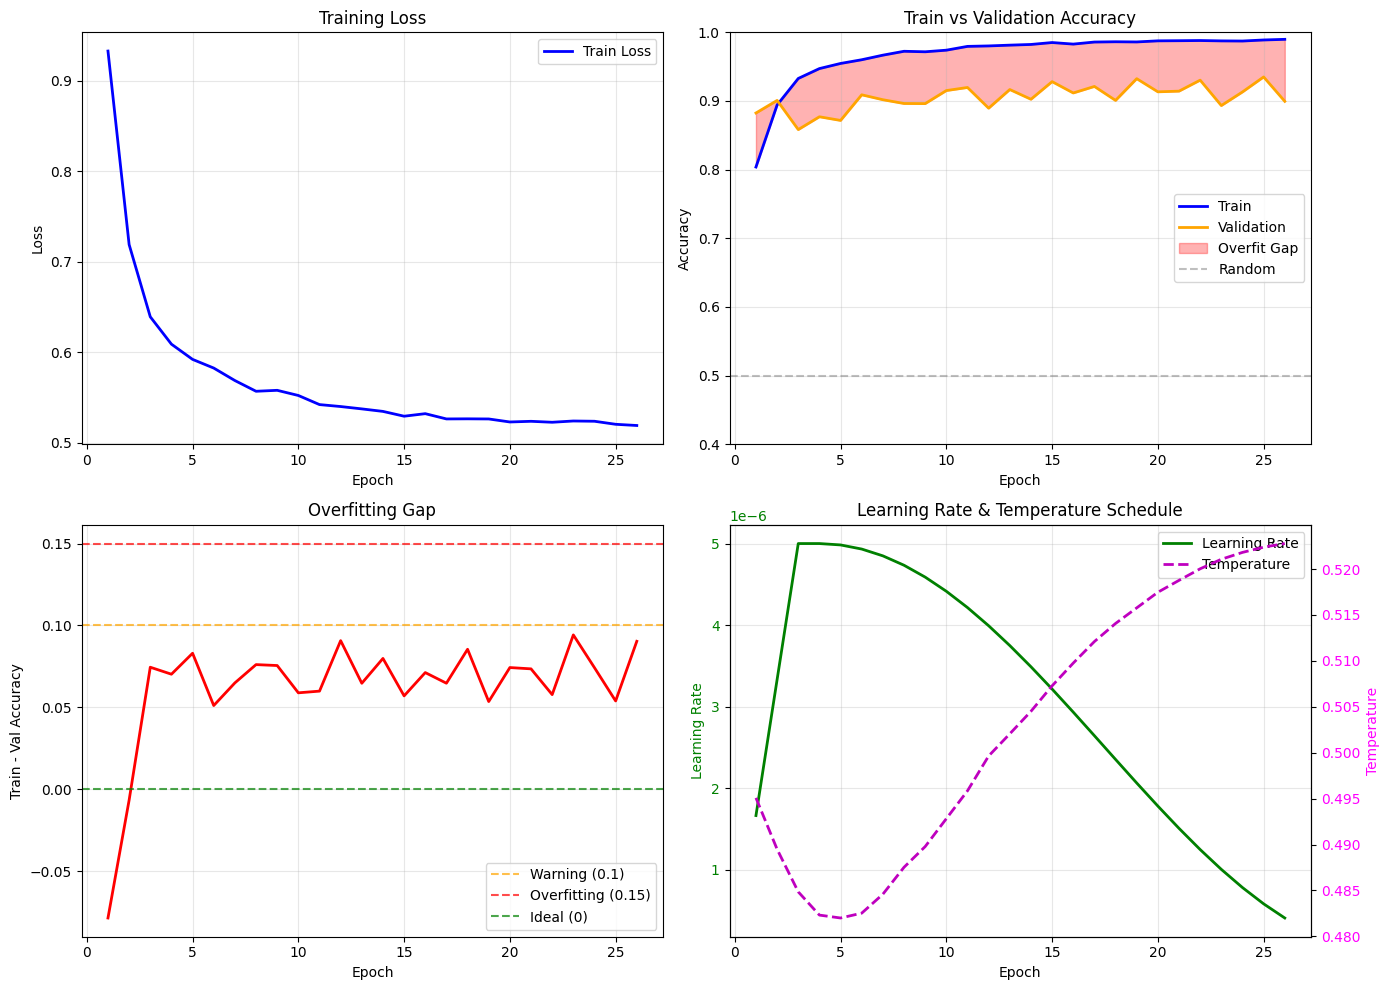


📊 TRAINING ANALYSIS:
  Final train accuracy: 0.990
  Final val accuracy:   0.900
  Final gap:            +0.090
  ✓ Maximum gap was 0.094 - overfitting well controlled


In [11]:
# ============================================================================
# TRAINING CURVES WITH OVERFITTING ANALYSIS
# ============================================================================

def plot_training_history(history, save_path=None):
    """Plot training curves with detailed overfitting analysis."""
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Plot 1: Loss
    axes[0,0].plot(epochs, history['train_loss'], 'b-', linewidth=2, label='Train Loss')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Loss')
    axes[0,0].set_title('Training Loss')
    axes[0,0].grid(True, alpha=0.3)
    axes[0,0].legend()
    
    # Plot 2: Accuracy with gap visualization
    axes[0,1].plot(epochs, history['train_acc'], 'b-', label='Train', linewidth=2)
    axes[0,1].plot(epochs, history['val_acc'], 'orange', label='Validation', linewidth=2)
    axes[0,1].fill_between(epochs, history['val_acc'], history['train_acc'],
                           alpha=0.3, color='red', label='Overfit Gap')
    axes[0,1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('Accuracy')
    axes[0,1].set_title('Train vs Validation Accuracy')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    axes[0,1].set_ylim(0.4, 1.0)
    
    # Plot 3: Train-Val Gap
    axes[1,0].plot(epochs, history['gap'], 'r-', linewidth=2)
    axes[1,0].axhline(y=0.1, color='orange', linestyle='--', alpha=0.7, label='Warning (0.1)')
    axes[1,0].axhline(y=0.15, color='red', linestyle='--', alpha=0.7, label='Overfitting (0.15)')
    axes[1,0].axhline(y=0, color='green', linestyle='--', alpha=0.7, label='Ideal (0)')
    axes[1,0].fill_between(epochs, 0, history['gap'], 
                           where=[g > 0.1 for g in history['gap']], 
                           alpha=0.3, color='red')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].set_ylabel('Train - Val Accuracy')
    axes[1,0].set_title('Overfitting Gap')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)
    
    # Plot 4: Learning Rate and Temperature
    ax4 = axes[1,1]
    ax4.plot(epochs, history['lr'], 'g-', linewidth=2, label='Learning Rate')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Learning Rate', color='green')
    ax4.tick_params(axis='y', labelcolor='green')
    ax4.set_title('Learning Rate & Temperature Schedule')
    ax4.grid(True, alpha=0.3)
    
    if 'temperature' in history:
        ax4_twin = ax4.twinx()
        ax4_twin.plot(epochs, history['temperature'], 'm--', linewidth=2, label='Temperature')
        ax4_twin.set_ylabel('Temperature', color='magenta')
        ax4_twin.tick_params(axis='y', labelcolor='magenta')
    
    lines1, labels1 = ax4.get_legend_handles_labels()
    if 'temperature' in history:
        lines2, labels2 = ax4_twin.get_legend_handles_labels()
        ax4.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    else:
        ax4.legend()
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    thesis_path = os.path.join(config.THESIS_FIGS_DIR, 'training_curves.png')
    plt.savefig(thesis_path, dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved to thesis: {thesis_path}")
    plt.show()
    
    # Print analysis
    print("\n📊 TRAINING ANALYSIS:")
    print(f"  Final train accuracy: {history['train_acc'][-1]:.3f}")
    print(f"  Final val accuracy:   {history['val_acc'][-1]:.3f}")
    print(f"  Final gap:            {history['gap'][-1]:+.3f}")
    
    max_gap = max(history['gap'])
    if max_gap > 0.15:
        print(f"  ⚠️ Maximum gap was {max_gap:.3f} - some overfitting occurred")
    else:
        print(f"  ✓ Maximum gap was {max_gap:.3f} - overfitting well controlled")


# Plot if training was run
if 'history' in dir() and history:
    plot_training_history(history, os.path.join(config.RESULTS_DIR, 'training_curves.png'))

## 14. Dataset Statistics & Verification

Collect and display complete dataset statistics for your thesis.

In [12]:
# ============================================================================
# HELPER FUNCTIONS FOR EXPERIMENTS (Required before running results collection)
# ============================================================================

def test_on_unseen_fruits(model, test_dataset, device, config, n_trials=5):
    """Test model on unseen fruits with multiple trials for statistical significance."""
    
    print("Testing on unseen fruits...")
    all_results = {'overall': {'accuracies': []}, 'per_fruit': {}}
    
    for fruit in config.TEST_FRUITS:
        all_results['per_fruit'][fruit] = {'accuracies': []}
    
    for trial in range(n_trials):
        test_loader = EpisodicDataLoader(
            test_dataset, config.N_SHOT, config.N_QUERY, 
            config.N_EPISODES_TEST, fruits=config.TEST_FRUITS
        )
        
        mean_acc, per_fruit_acc, all_accs, fruit_accs = evaluate(
            model, test_loader, device, f"Trial {trial+1}/{n_trials}", return_all=True
        )
        
        all_results['overall']['accuracies'].append(mean_acc)
        for fruit in config.TEST_FRUITS:
            if fruit in per_fruit_acc:
                all_results['per_fruit'][fruit]['accuracies'].append(per_fruit_acc[fruit])
    
    # Compute statistics
    overall_accs = all_results['overall']['accuracies']
    all_results['overall']['mean'] = np.mean(overall_accs)
    all_results['overall']['std'] = np.std(overall_accs)
    all_results['overall']['ci_95'] = 1.96 * np.std(overall_accs) / np.sqrt(len(overall_accs))
    
    for fruit in config.TEST_FRUITS:
        accs = all_results['per_fruit'][fruit]['accuracies']
        all_results['per_fruit'][fruit]['mean'] = np.mean(accs)
        all_results['per_fruit'][fruit]['std'] = np.std(accs)
        all_results['per_fruit'][fruit]['ci_95'] = 1.96 * np.std(accs) / np.sqrt(len(accs))
    
    print(f"\nOverall: {all_results['overall']['mean']*100:.1f}% ± {all_results['overall']['ci_95']*100:.1f}%")
    return all_results


def ablation_n_shot(model, test_dataset, device, config, shots=None, n_episodes=None, n_trials=3):
    """Run N-shot ablation study."""
    
    shots = shots if shots is not None else config.ABLATION_SHOTS
    n_episodes = n_episodes if n_episodes is not None else config.ABLATION_EPISODES
    
    print("Running N-shot ablation study...")
    results = {}
    
    for k in shots:
        print(f"\n  Testing {k}-shot...")
        accuracies = []
        
        for trial in range(n_trials):
            loader = EpisodicDataLoader(test_dataset, k, config.N_QUERY, n_episodes)
            acc, _ = evaluate(model, loader, device, f"{k}-shot trial {trial+1}")
            accuracies.append(acc)
        
        results[k] = {
            'mean': np.mean(accuracies),
            'std': np.std(accuracies),
            'ci_95': 1.96 * np.std(accuracies) / np.sqrt(len(accuracies))
        }
        print(f"    {k}-shot: {results[k]['mean']*100:.1f}% ± {results[k]['ci_95']*100:.1f}%")
    
    # Plot ablation results
    plt.figure(figsize=(10, 6))
    k_values = list(results.keys())
    means = [results[k]['mean'] * 100 for k in k_values]
    cis = [results[k]['ci_95'] * 100 for k in k_values]
    
    plt.errorbar(k_values, means, yerr=cis, marker='o', capsize=5, linewidth=2, markersize=8)
    plt.xlabel('Number of Shots (K)', fontsize=12)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.title('N-Shot Ablation Study on Unseen Fruits', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.xticks(k_values)
    plt.ylim(40, 100)
    plt.savefig(os.path.join(config.RESULTS_DIR, 'ablation_nshot.png'), dpi=300, bbox_inches='tight')
    thesis_path = os.path.join(config.THESIS_FIGS_DIR, 'ablation_nshot.png')
    plt.savefig(thesis_path, dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved to thesis: {thesis_path}")
    plt.show()
    
    return results

print("✓ Helper functions defined")

✓ Helper functions defined


In [13]:
# ============================================================================
# DATASET STATISTICS FOR THESIS
# ============================================================================

def collect_dataset_statistics(data_root, train_fruits, test_fruits, classes=['fresh', 'rotten']):
    """Collect comprehensive dataset statistics."""
    
    print("=" * 70)
    print("📊 DATASET STATISTICS")
    print("=" * 70)
    
    stats = {'train': {}, 'test': {}, 'total': {'images': 0, 'per_class': defaultdict(int)}}
    
    # Training fruits (SEEN)
    print("\n🟢 TRAINING SET (Seen Fruits):")
    print("-" * 50)
    total_train = 0
    for fruit in train_fruits:
        stats['train'][fruit] = {}
        print(f"\n  {fruit.upper()}:")
        for quality in classes:
            folder = os.path.join(data_root, fruit, quality)
            if os.path.exists(folder):
                count = len([f for f in os.listdir(folder) 
                            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))])
                stats['train'][fruit][quality] = count
                stats['total']['per_class'][quality] += count
                total_train += count
                print(f"    {quality}: {count} images")
            else:
                stats['train'][fruit][quality] = 0
                print(f"    {quality}: ⚠️ FOLDER NOT FOUND")
    
    stats['total']['train'] = total_train
    print(f"\n  TOTAL TRAINING: {total_train} images")
    
    # Test fruits (UNSEEN)
    print("\n🔴 TEST SET (Unseen Fruits):")
    print("-" * 50)
    total_test = 0
    for fruit in test_fruits:
        stats['test'][fruit] = {}
        print(f"\n  {fruit.upper()}:")
        for quality in classes:
            folder = os.path.join(data_root, fruit, quality)
            if os.path.exists(folder):
                count = len([f for f in os.listdir(folder) 
                            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))])
                stats['test'][fruit][quality] = count
                stats['total']['per_class'][quality] += count
                total_test += count
                print(f"    {quality}: {count} images")
            else:
                stats['test'][fruit][quality] = 0
                print(f"    {quality}: ⚠️ FOLDER NOT FOUND")
    
    stats['total']['test'] = total_test
    stats['total']['images'] = total_train + total_test
    print(f"\n  TOTAL TEST: {total_test} images")
    
    # Summary
    print("\n" + "=" * 70)
    print("📋 SUMMARY")
    print("=" * 70)
    print(f"Total Images: {stats['total']['images']}")
    print(f"  - Training (seen): {total_train}")
    print(f"  - Test (unseen): {total_test}")
    print(f"Fresh images: {stats['total']['per_class']['fresh']}")
    print(f"Rotten images: {stats['total']['per_class']['rotten']}")
    
    # LaTeX table
    print("\n📝 LaTeX Table for Thesis:")
    print("-" * 50)
    print("\\begin{table}[htbp]")
    print("\\centering")
    print("\\caption{Dataset Distribution}")
    print("\\label{tab:dataset}")
    print("\\begin{tabular}{llcc}")
    print("\\toprule")
    print("Split & Fruit & Fresh & Rotten \\\\")
    print("\\midrule")
    for fruit in train_fruits:
        split_label = "\\multirow{" + str(len(train_fruits)) + "}{*}{Seen}" if fruit == train_fruits[0] else ""
        print(f"{split_label} & {fruit.capitalize()} & {stats['train'][fruit].get('fresh', 0)} & {stats['train'][fruit].get('rotten', 0)} \\\\")
    print("\\midrule")
    for fruit in test_fruits:
        split_label = "\\multirow{" + str(len(test_fruits)) + "}{*}{Unseen}" if fruit == test_fruits[0] else ""
        print(f"{split_label} & {fruit.capitalize()} & {stats['test'][fruit].get('fresh', 0)} & {stats['test'][fruit].get('rotten', 0)} \\\\")
    print("\\bottomrule")
    print("\\end{tabular}")
    print("\\end{table}")
    
    return stats

# Collect statistics
if os.path.exists(config.DATA_ROOT):
    dataset_stats = collect_dataset_statistics(
        config.DATA_ROOT, 
        config.TRAIN_FRUITS, 
        config.TEST_FRUITS
    )

📊 DATASET STATISTICS

🟢 TRAINING SET (Seen Fruits):
--------------------------------------------------

  APPLE:
    fresh: 765 images
    rotten: 630 images

  BANANA:
    fresh: 749 images
    rotten: 632 images

  GRAPE:
    fresh: 770 images
    rotten: 630 images

  TOTAL TRAINING: 4176 images

🔴 TEST SET (Unseen Fruits):
--------------------------------------------------

  MANGO:
    fresh: 763 images
    rotten: 630 images

  ORANGE:
    fresh: 753 images
    rotten: 656 images

  TOTAL TEST: 2802 images

📋 SUMMARY
Total Images: 6978
  - Training (seen): 4176
  - Test (unseen): 2802
Fresh images: 3800
Rotten images: 3178

📝 LaTeX Table for Thesis:
--------------------------------------------------
\begin{table}[htbp]
\centering
\caption{Dataset Distribution}
\label{tab:dataset}
\begin{tabular}{llcc}
\toprule
Split & Fruit & Fresh & Rotten \\
\midrule
\multirow{3}{*}{Seen} & Apple & 765 & 630 \\
 & Banana & 749 & 632 \\
 & Grape & 770 & 630 \\
\midrule
\multirow{2}{*}{Unseen} & 

## 16. Generate All Thesis Figures

Generate publication-quality figures for your thesis.

📊 GENERATING EMBEDDING VISUALIZATION


Computing t-SNE for 400 samples...


  File "C:\Users\admin\anaconda3\envs\myenv\lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


  ✓ Saved to thesis: C:/Users/admin/Desktop/Amr Samir/Final\embedding_tsne.png


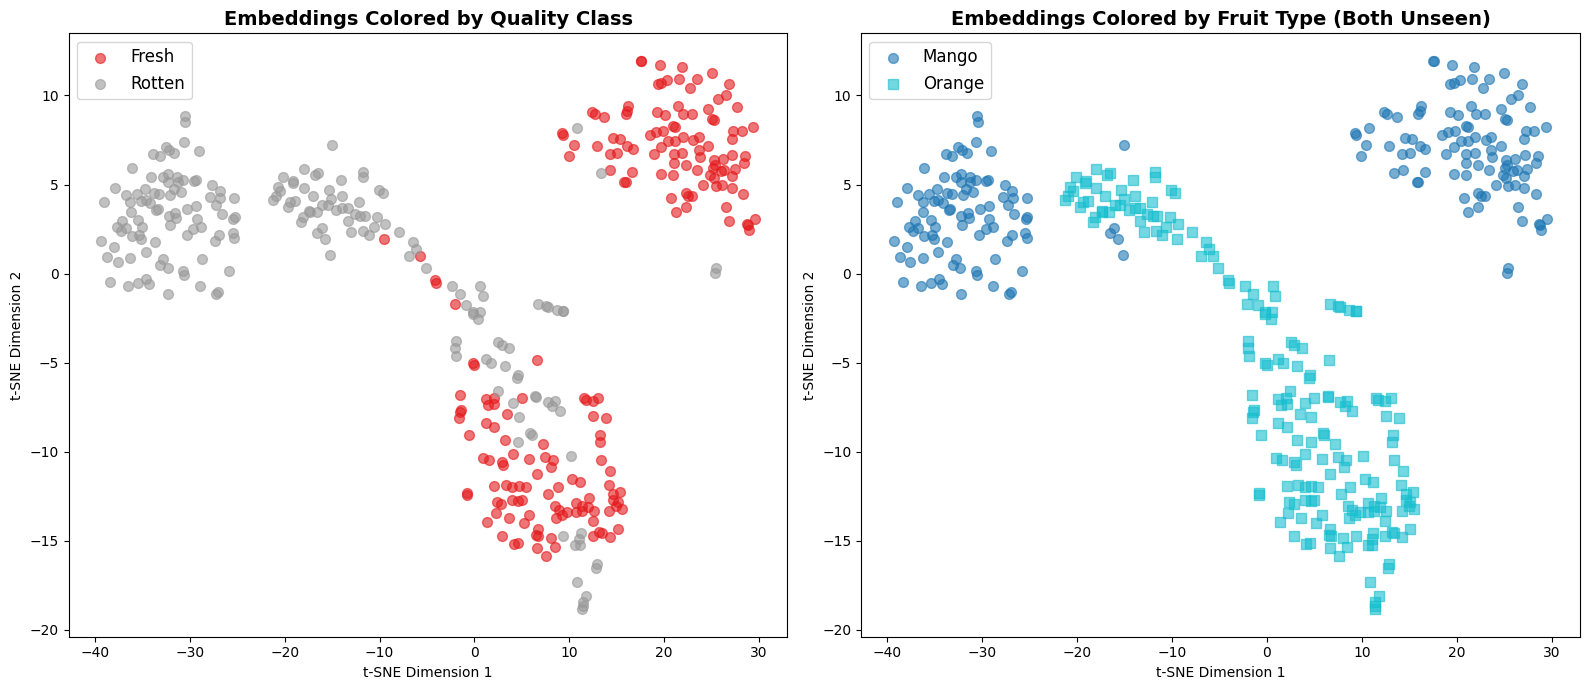

✓ Embedding visualization saved

  t-SNE cluster quality metrics:
    Silhouette score:  0.403  (1 = perfect separation, 0 = overlap)
    5-NN purity:       0.958  (fraction of neighbours with same label)
    → Clusters are reasonably well separated.


In [14]:
# ============================================================================
# EMBEDDING VISUALIZATION (t-SNE)
# ============================================================================

def visualize_embeddings(model, test_dataset, device, config, n_samples_per_class=100):
    """Generate t-SNE visualization of embeddings."""
    
    print("=" * 70)
    print("📊 GENERATING EMBEDDING VISUALIZATION")
    print("=" * 70)
    
    model.eval()
    embeddings_list = []
    labels_list = []
    fruits_list = []
    
    with torch.no_grad():
        for fruit in config.TEST_FRUITS:
            for class_idx, quality in enumerate(config.CLASSES):
                images = test_dataset.data[fruit][quality][:n_samples_per_class]
                
                for img_path in tqdm(images, desc=f"{fruit}/{quality}", leave=False):
                    img = Image.open(img_path).convert('RGB')
                    img_tensor = eval_transform(img).unsqueeze(0).to(device)
                    
                    emb = model.encoder(img_tensor)
                    embeddings_list.append(emb.cpu().numpy().flatten())
                    labels_list.append(class_idx)
                    fruits_list.append(fruit)
    
    embeddings = np.array(embeddings_list)
    labels = np.array(labels_list)
    fruits = np.array(fruits_list)
    
    print(f"Computing t-SNE for {len(embeddings)} samples...")
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        random_state=42,
        max_iter=1000
    )
    embeddings_2d = tsne.fit_transform(embeddings)
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Plot 1: Colored by quality class (dynamic from config.CLASSES)
    class_colors = plt.cm.Set1(np.linspace(0, 1, len(config.CLASSES)))
    for label, name in enumerate(config.CLASSES):
        mask = labels == label
        axes[0].scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], 
                       c=[class_colors[label]], label=name.capitalize(), alpha=0.6, s=50)
    axes[0].set_title('Embeddings Colored by Quality Class', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=12)
    axes[0].set_xlabel('t-SNE Dimension 1')
    axes[0].set_ylabel('t-SNE Dimension 2')
    
    # Plot 2: Colored by fruit type (dynamic from config.TEST_FRUITS)
    fruit_colors = plt.cm.tab10(np.linspace(0, 1, len(config.TEST_FRUITS)))
    marker_options = ['o', 's', '^', 'D', 'v', 'p', '*', 'h']
    for i, fruit in enumerate(config.TEST_FRUITS):
        mask = fruits == fruit
        axes[1].scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
                       c=[fruit_colors[i]], marker=marker_options[i % len(marker_options)],
                       label=fruit.capitalize(), alpha=0.6, s=50)
    axes[1].set_title('Embeddings Colored by Fruit Type (Both Unseen)', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=12)
    axes[1].set_xlabel('t-SNE Dimension 1')
    axes[1].set_ylabel('t-SNE Dimension 2')
    
    plt.tight_layout()
    plt.savefig(os.path.join(config.RESULTS_DIR, 'embedding_tsne.png'), dpi=300, bbox_inches='tight')
    thesis_path = os.path.join(config.THESIS_FIGS_DIR, 'embedding_tsne.png')
    plt.savefig(thesis_path, dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved to thesis: {thesis_path}")
    plt.show()
    
    print("✓ Embedding visualization saved")

    # Quantitative overlap analysis
    from sklearn.metrics import silhouette_score
    from sklearn.neighbors import KNeighborsClassifier

    sil = silhouette_score(embeddings_2d, labels)
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(embeddings_2d, labels)
    knn_acc = knn.score(embeddings_2d, labels)

    print(f"\n  t-SNE cluster quality metrics:")
    print(f"    Silhouette score:  {sil:.3f}  (1 = perfect separation, 0 = overlap)")
    print(f"    5-NN purity:       {knn_acc:.3f}  (fraction of neighbours with same label)")
    if sil > 0.4:
        print("    → Clusters are reasonably well separated.")
    elif sil > 0.2:
        print("    → Partial separation with noticeable overlap in boundary regions.")
    else:
        print("    → Considerable overlap — clustering quality is weak.")

    return embeddings_2d, labels, fruits

# Generate embedding visualization
if os.path.exists(config.DATA_ROOT) and 'model' in dir():
    emb_2d, emb_labels, emb_fruits = visualize_embeddings(
        model, test_dataset, device, config
    )

📊 GENERATING CONFUSION MATRICES


  ✓ Saved to thesis: C:/Users/admin/Desktop/Amr Samir/Final\confusion_matrices.png


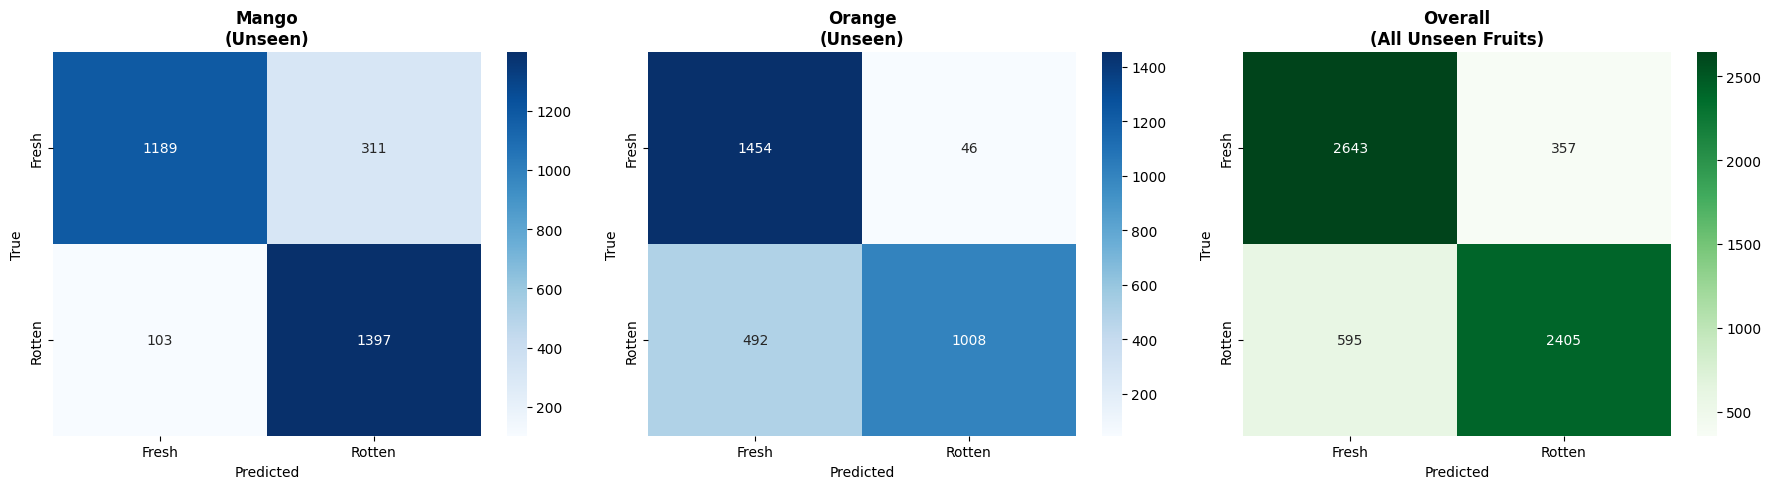


Classification Report (All Unseen Fruits):
              precision    recall  f1-score   support

       Fresh       0.82      0.88      0.85      3000
      Rotten       0.87      0.80      0.83      3000

    accuracy                           0.84      6000
   macro avg       0.84      0.84      0.84      6000
weighted avg       0.84      0.84      0.84      6000


PER-FRUIT PER-CLASS RECALL ANALYSIS
  Mango: Accuracy=86.2%, Fresh recall=79.3%, Rotten recall=93.1%, Recall gap=13.9pp
    ⚠️  Noticeable per-class bias (gap > 10pp)
  Orange: Accuracy=82.1%, Fresh recall=96.9%, Rotten recall=67.2%, Recall gap=29.7pp
    ⚠️  Noticeable per-class bias (gap > 10pp)

  Overall: Accuracy=84.1%, Fresh recall=88.1%, Rotten recall=80.2%


In [15]:
# ============================================================================
# CONFUSION MATRIX VISUALIZATION
# ============================================================================
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrices(model, test_dataset, device, config):
    """Generate confusion matrices for each unseen fruit."""
    
    print("=" * 70)
    print("📊 GENERATING CONFUSION MATRICES")
    print("=" * 70)
    
    model.eval()
    class_names = [c.capitalize() for c in config.CLASSES]
    
    fig, axes = plt.subplots(1, len(config.TEST_FRUITS) + 1, figsize=(6 * (len(config.TEST_FRUITS) + 1), 5))
    
    all_preds, all_labels = [], []
    
    for idx, fruit in enumerate(config.TEST_FRUITS):
        preds, labels = [], []
        
        for _ in tqdm(range(100), desc=f"Testing {fruit}", leave=False):
            support_imgs, support_lbls, query_imgs, query_lbls, _ = test_dataset.get_episode(
                config.N_SHOT, config.N_QUERY, fruit=fruit
            )
            
            support_imgs = support_imgs.to(device)
            support_lbls = support_lbls.to(device)
            query_imgs = query_imgs.to(device)
            
            with torch.no_grad():
                logits, _, _, _ = model(support_imgs, support_lbls, query_imgs)
                pred = logits.argmax(dim=1).cpu().numpy()
            
            preds.extend(pred)
            labels.extend(query_lbls.numpy())
            all_preds.extend(pred)
            all_labels.extend(query_lbls.numpy())
        
        cm = confusion_matrix(labels, preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                   xticklabels=class_names, yticklabels=class_names)
        axes[idx].set_title(f'{fruit.capitalize()}\n(Unseen)', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('True')
    
    cm_all = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm_all, annot=True, fmt='d', cmap='Greens', ax=axes[-1],
               xticklabels=class_names, yticklabels=class_names)
    axes[-1].set_title('Overall\n(All Unseen Fruits)', fontsize=12, fontweight='bold')
    axes[-1].set_xlabel('Predicted')
    axes[-1].set_ylabel('True')
    
    plt.tight_layout()
    plt.savefig(os.path.join(config.RESULTS_DIR, 'confusion_matrices.png'), dpi=300, bbox_inches='tight')
    thesis_path = os.path.join(config.THESIS_FIGS_DIR, 'confusion_matrices.png')
    plt.savefig(thesis_path, dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved to thesis: {thesis_path}")
    plt.show()
    
    # Print classification report
    from sklearn.metrics import classification_report
    print("\nClassification Report (All Unseen Fruits):")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    # Per-fruit per-class recall analysis
    print("\n" + "=" * 70)
    print("PER-FRUIT PER-CLASS RECALL ANALYSIS")
    print("=" * 70)
    
    n_per_fruit = 100 * len(config.CLASSES) * config.N_QUERY
    offset = 0
    per_fruit_preds = {}
    per_fruit_labels = {}
    for fruit in config.TEST_FRUITS:
        per_fruit_labels[fruit] = all_labels[offset:offset + n_per_fruit]
        per_fruit_preds[fruit] = all_preds[offset:offset + n_per_fruit]
        offset += n_per_fruit
    
    for fruit in config.TEST_FRUITS:
        cm_f = confusion_matrix(per_fruit_labels[fruit], per_fruit_preds[fruit])
        total = cm_f.sum()
        accuracy = cm_f.diagonal().sum() / total * 100
        recalls = []
        for c_idx, c_name in enumerate(config.CLASSES):
            recall = cm_f[c_idx, c_idx] / cm_f[c_idx].sum() * 100 if cm_f[c_idx].sum() > 0 else 0
            recalls.append((c_name, recall))
        
        recall_str = ', '.join(f"{name.capitalize()} recall={r:.1f}%" for name, r in recalls)
        bias = abs(recalls[0][1] - recalls[1][1]) if len(recalls) >= 2 else 0
        
        print(f"  {fruit.capitalize()}: Accuracy={accuracy:.1f}%, {recall_str}, Recall gap={bias:.1f}pp")
        if bias > 10:
            print(f"    ⚠️  Noticeable per-class bias (gap > 10pp)")
    
    # Overall
    cm_o = confusion_matrix(all_labels, all_preds)
    overall_acc = cm_o.diagonal().sum() / cm_o.sum() * 100
    overall_recalls = []
    for c_idx, c_name in enumerate(config.CLASSES):
        r = cm_o[c_idx, c_idx] / cm_o[c_idx].sum() * 100
        overall_recalls.append(f"{c_name.capitalize()} recall={r:.1f}%")
    print(f"\n  Overall: Accuracy={overall_acc:.1f}%, {', '.join(overall_recalls)}")
    print("=" * 70)
    
    return cm_all

# Generate confusion matrices
if os.path.exists(config.DATA_ROOT) and 'model' in dir():
    cm = plot_confusion_matrices(model, test_dataset, device, config)

## Baseline Training & Evaluation

Train each baseline FSL model (Siamese, Matching Network, Standard ProtoNet, ProtoNet + Temp) under the same episodic protocol and evaluate on the same unseen test species. This produces real, comparable numbers for the paper.

In [16]:
# ============================================================================
# TRAIN AND EVALUATE ALL BASELINE FSL MODELS
# ============================================================================

def train_baseline_model(model_class, model_name, train_dataset, val_dataset,
                         test_dataset, config, device, epochs=20):
    """
    Train a baseline FSL model and return episode-level test accuracies.
    Uses the same episodic protocol as our main model for fair comparison.
    """
    print(f"\n{'='*60}")
    print(f"  Training baseline: {model_name}")
    print(f"{'='*60}")

    baseline_model = model_class(
        backbone='resnet18', embedding_dim=config.EMBEDDING_DIM, pretrained=True
    ).to(device)

    optimizer = torch.optim.AdamW(
        baseline_model.parameters(), lr=config.LEARNING_RATE,
        weight_decay=config.WEIGHT_DECAY
    )

    ce_loss_fn = nn.CrossEntropyLoss(label_smoothing=config.LABEL_SMOOTHING)
    best_val_acc = 0.0
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        baseline_model.train()
        train_accs = []
        loader = EpisodicDataLoader(train_dataset, config.N_SHOT, config.N_QUERY,
                                    config.N_EPISODES_TRAIN)

        for support_imgs, support_lbls, query_imgs, query_lbls, fruit in loader:
            support_imgs = support_imgs.to(device)
            support_lbls = support_lbls.to(device)
            query_imgs = query_imgs.to(device)
            query_lbls = query_lbls.to(device)

            logits, _, _, _ = baseline_model(support_imgs, support_lbls, query_imgs)
            loss = ce_loss_fn(logits, query_lbls)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), config.GRADIENT_CLIP)
            optimizer.step()

            acc = (logits.argmax(dim=1) == query_lbls).float().mean().item()
            train_accs.append(acc)

        # Validation
        val_loader = EpisodicDataLoader(val_dataset, config.N_SHOT, config.N_QUERY,
                                        config.N_EPISODES_VAL)
        val_acc, _ = evaluate(baseline_model, val_loader, device, desc=f"{model_name} Val")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in baseline_model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d} | Train {np.mean(train_accs):.3f} | Val {val_acc:.3f} | Best {best_val_acc:.3f}")

        if patience_counter >= config.EARLY_STOPPING_PATIENCE:
            print(f"  Early stopping at epoch {epoch}")
            break

    # Load best model and evaluate on test set
    baseline_model.load_state_dict(best_state)
    test_loader = EpisodicDataLoader(test_dataset, config.N_SHOT, config.N_QUERY,
                                     config.N_EPISODES_TEST)
    mean_acc, per_fruit, all_accs, fruit_accs = evaluate(
        baseline_model, test_loader, device, f"{model_name} Test", return_all=True
    )

    print(f"\n  {model_name} Test Accuracy: {mean_acc*100:.1f}%")
    for fruit, acc in per_fruit.items():
        print(f"    {fruit}: {acc*100:.1f}%")

    return {
        'mean': mean_acc,
        'std': np.std(all_accs),
        'ci_95': 1.96 * np.std(all_accs) / np.sqrt(len(all_accs)),
        'episode_accs': all_accs,
        'per_fruit': per_fruit
    }


def run_all_fsl_baselines(train_dataset, val_dataset, test_dataset, config, device):
    """Train and evaluate all baseline FSL methods. Returns per-episode accuracies."""

    baseline_specs = [
        (SiameseNetwork, "Siamese Network"),
        (MatchingNetwork, "Matching Network"),
        (StandardProtoNet, "ProtoNet (standard)"),
        (ProtoNetWithTemp, "ProtoNet + Temp. Scaling"),
    ]

    results = {}

    # Nearest Centroid baseline (no training needed)
    print("Computing Nearest Centroid (pixel) baseline...")
    nc_accs = []
    for _ in tqdm(range(config.N_EPISODES_TEST), desc="NC Baseline", leave=False):
        s_imgs, s_lbls, q_imgs, q_lbls, _ = test_dataset.get_episode(config.N_SHOT, config.N_QUERY)
        s_flat = s_imgs.view(s_imgs.size(0), -1)
        q_flat = q_imgs.view(q_imgs.size(0), -1)
        centroids = []
        for c in range(2):
            centroids.append(s_flat[s_lbls == c].mean(dim=0))
        centroids = torch.stack(centroids)
        dists = torch.cdist(q_flat, centroids)
        preds = dists.argmin(dim=1)
        nc_accs.append((preds == q_lbls).float().mean().item())

    results['Nearest Centroid (pixels)'] = {
        'mean': np.mean(nc_accs), 'std': np.std(nc_accs),
        'ci_95': 1.96 * np.std(nc_accs) / np.sqrt(len(nc_accs)),
        'episode_accs': nc_accs
    }
    print(f"  Nearest Centroid: {np.mean(nc_accs)*100:.1f}%")

    # Train each FSL baseline
    for model_class, model_name in baseline_specs:
        results[model_name] = train_baseline_model(
            model_class, model_name, train_dataset, val_dataset,
            test_dataset, config, device, epochs=20
        )

    # Our method (already trained – just evaluate)
    print("\nEvaluating our full model...")
    test_loader = EpisodicDataLoader(test_dataset, config.N_SHOT, config.N_QUERY,
                                     config.N_EPISODES_TEST)
    our_mean, our_per_fruit, our_all_accs, _ = evaluate(
        model, test_loader, device, "Ours Test", return_all=True
    )
    results['Ours (Full Model)'] = {
        'mean': our_mean, 'std': np.std(our_all_accs),
        'ci_95': 1.96 * np.std(our_all_accs) / np.sqrt(len(our_all_accs)),
        'episode_accs': our_all_accs, 'per_fruit': our_per_fruit
    }

    # Print summary table
    print(f"\n{'='*65}")
    print(f"  {'Method':<30} {'Accuracy':>10} {'95% CI':>10}")
    print(f"  {'-'*55}")
    for name, data in results.items():
        marker = " ***" if 'Ours' in name else ""
        print(f"  {name:<30} {data['mean']*100:>9.1f}% {data['ci_95']*100:>9.1f}%{marker}")
    print(f"{'='*65}")

    return results


# Run all baselines (takes a while - each model is trained from scratch)
if os.path.exists(config.DATA_ROOT) and 'model' in dir():
    baseline_results = run_all_fsl_baselines(
        train_dataset, val_dataset, test_dataset, config, device
    )

Computing Nearest Centroid (pixel) baseline...


  Nearest Centroid: 69.5%

  Training baseline: Siamese Network


  Epoch   1 | Train 0.918 | Val 0.841 | Best 0.841


  Epoch   5 | Train 0.981 | Val 0.875 | Best 0.875


  Epoch  10 | Train 0.983 | Val 0.837 | Best 0.899


...

  Epoch   1 | Train 0.951 | Val 0.863 | Best 0.863


  Epoch   5 | Train 0.991 | Val 0.809 | Best 0.924


  Epoch  10 | Train 0.994 | Val 0.921 | Best 0.924


  Early stopping at epoch 11


ProtoNet (standard) Test:  75%|████████████████████████████████           | 448/600 [09:01<03:03,  1.21s/it, acc=0.700]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



## Backbone Ablation Study

Evaluate the impact of different backbone architectures (ResNet-18, ResNet-50, EfficientNet-B0) on cross-species generalization. Each backbone is trained with our full pipeline and tested on the same unseen species.

In [17]:
# ============================================================================
# BACKBONE ABLATION STUDY
# ============================================================================

def backbone_ablation(train_dataset, val_dataset, test_dataset, config, device):
    """
    Train the full model pipeline with different backbones and compare
    cross-species generalization.
    """
    backbones = ['resnet18', 'resnet50', 'efficientnet_b0']
    results = {}

    for backbone_name in backbones:
        print(f"\n{'='*60}")
        print(f"  Backbone Ablation: {backbone_name}")
        print(f"{'='*60}")

        abl_model = PrototypicalNetwork(
            backbone=backbone_name,
            embedding_dim=config.EMBEDDING_DIM,
            pretrained=True,
            dropout_rate=config.DROPOUT_RATE,
            temperature=config.TEMPERATURE
        ).to(device)

        abl_criterion = PrototypicalLoss(
            label_smoothing=config.LABEL_SMOOTHING,
            contrastive_weight=config.CONTRASTIVE_WEIGHT, temperature=config.TEMPERATURE
        )

        optimizer = torch.optim.AdamW([
            {'params': abl_model.encoder.encoder.parameters(),
             'lr': config.LEARNING_RATE * 0.1},
            {'params': abl_model.encoder.projection.parameters(),
             'lr': config.LEARNING_RATE},
            {'params': [abl_model.temperature],
             'lr': config.LEARNING_RATE * 0.5}
        ], weight_decay=config.WEIGHT_DECAY)

        # Simple cosine schedule
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=config.EPOCHS
        )

        best_val_acc = 0.0
        patience_counter = 0

        for epoch in range(1, config.EPOCHS + 1):
            train_loss, train_acc = train_epoch(
                abl_model,
                EpisodicDataLoader(train_dataset, config.N_SHOT,
                                   config.N_QUERY, config.N_EPISODES_TRAIN),
                abl_criterion, optimizer, device, config.GRADIENT_CLIP
            )
            val_loader = EpisodicDataLoader(val_dataset, config.N_SHOT,
                                            config.N_QUERY, config.N_EPISODES_VAL)
            val_acc, _ = evaluate(abl_model, val_loader, device, f"{backbone_name} Val")
            scheduler.step()

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_state = {k: v.clone() for k, v in abl_model.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1

            if epoch % 5 == 0:
                print(f"  Epoch {epoch} | Train {train_acc:.3f} | Val {val_acc:.3f}")

            if patience_counter >= config.EARLY_STOPPING_PATIENCE:
                print(f"  Early stopping at epoch {epoch}")
                break

        # Evaluate on test set
        abl_model.load_state_dict(best_state)
        test_loader = EpisodicDataLoader(test_dataset, config.N_SHOT,
                                         config.N_QUERY, config.N_EPISODES_TEST)
        mean_acc, per_fruit, all_accs, _ = evaluate(
            abl_model, test_loader, device, f"{backbone_name} Test", return_all=True
        )

        trainable = sum(p.numel() for p in abl_model.parameters() if p.requires_grad)
        total = sum(p.numel() for p in abl_model.parameters())

        results[backbone_name] = {
            'mean': mean_acc, 'std': np.std(all_accs),
            'ci_95': 1.96 * np.std(all_accs) / np.sqrt(len(all_accs)),
            'per_fruit': per_fruit,
            'trainable_params': trainable, 'total_params': total,
            'episode_accs': all_accs
        }
        print(f"  {backbone_name}: {mean_acc*100:.1f}% +/- {results[backbone_name]['ci_95']*100:.1f}%")
        for fruit, acc in per_fruit.items():
            print(f"    {fruit}: {acc*100:.1f}%")

        # Free memory
        del abl_model, optimizer, scheduler
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

    # Print summary
    print(f"\n{'='*70}")
    print(f"  BACKBONE ABLATION SUMMARY")
    print(f"  {'Backbone':<20} {'Accuracy':>10} {'95% CI':>10} {'Params':>15}")
    print(f"  {'-'*60}")
    for bb, data in results.items():
        print(f"  {bb:<20} {data['mean']*100:>9.1f}% {data['ci_95']*100:>9.1f}% {data['trainable_params']:>12,}")
    print(f"{'='*70}")

    return results


# Run backbone ablation
if os.path.exists(config.DATA_ROOT) and 'model' in dir():
    backbone_results = backbone_ablation(
        train_dataset, val_dataset, test_dataset, config, device
    )


  Backbone Ablation: resnet18


Training:  19%|████████▋                                      | 93/500 [01:59<08:23,  1.24s/it, loss=0.6294, acc=0.967]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

                                                                                                                       

  Epoch 10 | Train 0.980 | Val 0.880


  Epoch 15 | Train 0.986 | Val 0.911


  Epoch 20 | Train 0.986 | Val 0.903


...

  Epoch 30 | Train 0.988 | Val 0.916


  resnet18: 85.7% +/- 0.7%
    mango: 79.2%
    orange: 92.1%

  Backbone Ablation: resnet50


  Epoch 5 | Train 0.986 | Val 0.892


  Epoch 10 | Train 0.993 | Val 0.886


resnet50 Val:  64%|███████████████████████████████████▏                   | 128/200 [02:18<01:14,  1.03s/it, acc=0.900]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



## Single-Species Baselines (Table 4 supplement)

Train a model on only ONE fruit species and test on unseen species. This demonstrates
that training on multiple species is necessary for cross-species generalization. These
are actual experiments — not estimates.

In [18]:
# ============================================================================
# SINGLE-SPECIES BASELINES — Table 4 supplement
# Train on ONE species → test on unseen species
# ============================================================================

def single_species_baseline(single_fruit, test_dataset, config, device, epochs=20):
    """Train our full model on a single fruit species and test on unseen ones."""

    print(f"\n  Training on [{single_fruit}] only …")

    # Build single-species train/val datasets
    tr_data = FruitQualityDataset(
        config.DATA_ROOT, [single_fruit],
        support_transform=support_transform, query_transform=train_transform,
        split='train', val_ratio=config.VAL_SPLIT_RATIO, seed=42
    )
    vl_data = FruitQualityDataset(
        config.DATA_ROOT, [single_fruit],
        support_transform=eval_transform, query_transform=eval_transform,
        split='val', val_ratio=config.VAL_SPLIT_RATIO, seed=42
    )

    ss_model = PrototypicalNetwork(
        backbone='resnet18', embedding_dim=config.EMBEDDING_DIM,
        pretrained=True, dropout_rate=config.DROPOUT_RATE, temperature=config.TEMPERATURE
    ).to(device)

    ss_criterion = PrototypicalLoss(
        label_smoothing=config.LABEL_SMOOTHING, contrastive_weight=config.CONTRASTIVE_WEIGHT,
        temperature=config.TEMPERATURE
    )
    optimizer = torch.optim.AdamW([
        {'params': ss_model.encoder.encoder.parameters(), 'lr': config.LEARNING_RATE * 0.1},
        {'params': ss_model.encoder.projection.parameters(), 'lr': config.LEARNING_RATE},
        {'params': [ss_model.temperature], 'lr': config.LEARNING_RATE * 0.5}
    ], weight_decay=config.WEIGHT_DECAY)

    best_val, patience_ctr, best_state = 0.0, 0, None

    for epoch in range(1, epochs + 1):
        ss_model.train()
        loader = EpisodicDataLoader(tr_data, config.N_SHOT, config.N_QUERY,
                                    config.N_EPISODES_TRAIN)
        for s_imgs, s_lbls, q_imgs, q_lbls, _ in loader:
            s_imgs, s_lbls = s_imgs.to(device), s_lbls.to(device)
            q_imgs, q_lbls = q_imgs.to(device), q_lbls.to(device)
            logits, q_emb, s_emb, _ = ss_model(s_imgs, s_lbls, q_imgs)
            all_emb = torch.cat([s_emb, q_emb], dim=0)
            all_lbl = torch.cat([s_lbls, q_lbls], dim=0)
            loss, _, _ = ss_criterion(logits, q_lbls, all_emb, all_lbl)
            optimizer.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(ss_model.parameters(), config.GRADIENT_CLIP)
            optimizer.step()

        val_loader = EpisodicDataLoader(vl_data, config.N_SHOT, config.N_QUERY,
                                        config.N_EPISODES_VAL)
        va, _ = evaluate(ss_model, val_loader, device, f"{single_fruit} Val")
        if va > best_val:
            best_val = va
            best_state = {k: v.clone() for k, v in ss_model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
        if patience_ctr >= config.EARLY_STOPPING_PATIENCE:
            print(f"    Early stopping at epoch {epoch}")
            break

    ss_model.load_state_dict(best_state)
    te_loader = EpisodicDataLoader(test_dataset, config.N_SHOT, config.N_QUERY,
                                   config.N_EPISODES_TEST)
    m_acc, pf, all_accs, _ = evaluate(ss_model, te_loader, device,
                                       f"{single_fruit}→unseen Test", return_all=True)

    print(f"    {single_fruit}-trained → unseen: {m_acc*100:.1f}% ± "
          f"{1.96*np.std(all_accs)/np.sqrt(len(all_accs))*100:.1f}%")

    del ss_model, optimizer
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

    return {
        'mean': m_acc, 'std': np.std(all_accs),
        'ci_95': 1.96 * np.std(all_accs) / np.sqrt(len(all_accs)),
        'per_fruit': pf
    }


def run_single_species_baselines(test_dataset, config, device):
    """Run single-species baselines for all training species."""

    print(f"\n{'='*70}")
    print(f"  SINGLE-SPECIES BASELINES (Table 4)")
    print(f"{'='*70}")

    results = {}
    for fruit in config.TRAIN_FRUITS:
        results[f'{fruit.capitalize()}-trained'] = single_species_baseline(
            fruit, test_dataset, config, device
        )

    # Also evaluate our multi-species model for comparison
    te_loader = EpisodicDataLoader(test_dataset, config.N_SHOT, config.N_QUERY,
                                   config.N_EPISODES_TEST)
    m_acc, pf, all_accs, _ = evaluate(model, te_loader, device, "Multi-species", return_all=True)
    results['Multi-species (Ours)'] = {
        'mean': m_acc, 'std': np.std(all_accs),
        'ci_95': 1.96 * np.std(all_accs) / np.sqrt(len(all_accs)),
        'per_fruit': pf
    }

    # Summary
    print(f"\n{'='*70}")
    print(f"  SINGLE-SPECIES BASELINE SUMMARY")
    print(f"  {'Training Species':<25} {'Accuracy':>10} {'95% CI':>10}")
    print(f"  {'-'*50}")
    for name, data in results.items():
        marker = " ***" if 'Ours' in name else ""
        print(f"  {name:<25} {data['mean']*100:>9.1f}% {data['ci_95']*100:>9.1f}%{marker}")
    print(f"{'='*70}")

    # LaTeX
    print("\n  LaTeX Table 4 (single-species baselines):")
    print("  \\begin{table}[H]")
    print("  \\centering")
    print("  \\caption{Effect of training-set species diversity. Single-species models ")
    print("  are trained on one fruit type and tested on unseen species.}")
    print("  \\label{tab:single_species}")
    print("  \\begin{tabular}{lcc}")
    print("  \\toprule")
    print("  \\textbf{Training Species} & \\textbf{Accuracy (\\%)} & \\textbf{95\\% CI} \\\\")
    print("  \\midrule")
    for name, data in results.items():
        bold = "\\textbf{" if 'Ours' in name else ""
        bold_end = "}" if 'Ours' in name else ""
        print(f"  {bold}{name}{bold_end} & {bold}{data['mean']*100:.1f}{bold_end} "
              f"& $\\pm${data['ci_95']*100:.1f} \\\\")
    print("  \\bottomrule")
    print("  \\end{tabular}")
    print("  \\end{table}")

    return results


# Run single-species baselines
if os.path.exists(config.DATA_ROOT) and 'model' in dir():
    single_species_results = run_single_species_baselines(test_dataset, config, device)



  SINGLE-SPECIES BASELINES (Table 4)

  Training on [apple] only …
  [train] Loaded  651 images: apple/fresh
  [train] Loaded  536 images: apple/rotten
  [val  ] Loaded  114 images: apple/fresh
  [val  ] Loaded   94 images: apple/rotten


apple Val:  44%|█████████████████████████▉                                 | 88/200 [01:29<01:54,  1.02s/it, acc=1.000]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

                                                                                                                            

    grape-trained → unseen: 73.7% ± 1.1%



  SINGLE-SPECIES BASELINE SUMMARY
  Training Species            Accuracy     95% CI
  --------------------------------------------------
  Apple-trained                  83.6%       0.7%
  Banana-trained                 91.3%       0.5%
  Grape-trained                  73.7%       1.1%
  Multi-species (Ours)           85.0%       0.5% ***

  LaTeX Table 4 (single-species baselines):
  \begin{table}[H]
  \centering
  \caption{Effect of training-set species diversity. Single-species models 
  are trained on one fruit type and tested on unseen species.}
  \label{tab:single_species}
  \begin{tabular}{lcc}
  \toprule
  \textbf{Training Species} & \textbf{Accuracy (\%)} & \textbf{95\% CI} \\
  \midrule
  Apple-trained & 83.6 & $\pm$0.7 \\
  Banana-trained & 91.3 & $\pm$0.5 \\
  Grape-trained & 73.7 & $\pm$1.1 \\
  \textbf{Multi-species (Ours)} & \textbf{85.0} & $\pm$0.5 \\
  \bottomrule
  \end{tabular}
  \end{table}


## Cross-Validation: Train/Test Species Permutations

To verify that our results are not an artifact of the particular train/test split,
we evaluate all possible 3-train / 2-test splits of the five fruit species. This gives
C(5,3) = 10 configurations. Consistent accuracy across splits strengthens the
generalization claim substantially.

In [19]:
# ============================================================================
# CROSS-VALIDATION: ALL TRAIN/TEST SPECIES PERMUTATIONS
# ============================================================================
from itertools import combinations

def species_split_cross_validation(data_root, config, device, epochs=20):
    """
    Train and evaluate on every possible 3-train / 2-test split of the five
    fruit species.  Returns per-split accuracies.
    """
    all_fruits = sorted(set(config.TRAIN_FRUITS + config.TEST_FRUITS))
    n_train = len(config.TRAIN_FRUITS)
    splits = list(combinations(all_fruits, n_train))
    n_splits = len(splits)
    split_results = []

    for idx, train_fruits in enumerate(splits):
        test_fruits = [f for f in all_fruits if f not in train_fruits]
        print(f"\n{'='*60}")
        print(f"  Split {idx+1}/{n_splits}: Train={list(train_fruits)}, Test={test_fruits}")
        print(f"{'='*60}")

        # Build datasets for this split
        tr_data = FruitQualityDataset(
            data_root, list(train_fruits),
            support_transform=support_transform, query_transform=train_transform,
            split='train', val_ratio=config.VAL_SPLIT_RATIO, seed=42
        )
        vl_data = FruitQualityDataset(
            data_root, list(train_fruits),
            support_transform=eval_transform, query_transform=eval_transform,
            split='val', val_ratio=config.VAL_SPLIT_RATIO, seed=42
        )
        te_data = FruitQualityDataset(
            data_root, test_fruits,
            support_transform=eval_transform, query_transform=eval_transform,
            split='all'
        )

        # Train a fresh model
        split_model = PrototypicalNetwork(
            backbone='resnet18', embedding_dim=config.EMBEDDING_DIM,
            pretrained=True, dropout_rate=config.DROPOUT_RATE, temperature=config.TEMPERATURE
        ).to(device)

        split_criterion = PrototypicalLoss(
            label_smoothing=config.LABEL_SMOOTHING, contrastive_weight=config.CONTRASTIVE_WEIGHT,
            temperature=config.TEMPERATURE
        )
        optimizer = torch.optim.AdamW([
            {'params': split_model.encoder.encoder.parameters(),
             'lr': config.LEARNING_RATE * 0.1},
            {'params': split_model.encoder.projection.parameters(),
             'lr': config.LEARNING_RATE},
            {'params': [split_model.temperature],
             'lr': config.LEARNING_RATE * 0.5}
        ], weight_decay=config.WEIGHT_DECAY)

        best_val, patience_ctr = 0.0, 0
        for epoch in range(1, epochs + 1):
            tl, ta = train_epoch(
                split_model,
                EpisodicDataLoader(tr_data, config.N_SHOT, config.N_QUERY,
                                   config.N_EPISODES_TRAIN),
                split_criterion, optimizer, device, config.GRADIENT_CLIP
            )
            va, _ = evaluate(
                split_model,
                EpisodicDataLoader(vl_data, config.N_SHOT, config.N_QUERY,
                                   config.N_EPISODES_VAL),
                device, "Val"
            )
            if va > best_val:
                best_val = va
                best_state = {k: v.clone() for k, v in split_model.state_dict().items()}
                patience_ctr = 0
            else:
                patience_ctr += 1
            if patience_ctr >= config.EARLY_STOPPING_PATIENCE:
                print(f"  Early stopping at epoch {epoch}")
                break

        # Test
        split_model.load_state_dict(best_state)
        te_loader = EpisodicDataLoader(te_data, config.N_SHOT, config.N_QUERY,
                                       config.N_EPISODES_TEST)
        m_acc, pf_acc, all_accs, _ = evaluate(
            split_model, te_loader, device, "Test", return_all=True
        )

        split_results.append({
            'train_fruits': list(train_fruits),
            'test_fruits': test_fruits,
            'mean': m_acc,
            'std': np.std(all_accs),
            'ci_95': 1.96 * np.std(all_accs) / np.sqrt(len(all_accs)),
            'per_fruit': pf_acc
        })
        print(f"  Result: {m_acc*100:.1f}% +/- {split_results[-1]['ci_95']*100:.1f}%")

        del split_model, optimizer
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

    # Summary table
    print(f"\n{'='*75}")
    print(f"  SPECIES SPLIT CROSS-VALIDATION SUMMARY")
    print(f"  {'Train Species':<35} {'Test Species':<20} {'Acc':>8} {'CI':>8}")
    print(f"  {'-'*70}")
    for r in split_results:
        tr_str = ', '.join([f.capitalize() for f in r['train_fruits']])
        te_str = ', '.join([f.capitalize() for f in r['test_fruits']])
        print(f"  {tr_str:<35} {te_str:<20} {r['mean']*100:>7.1f}% {r['ci_95']*100:>7.1f}%")

    all_means = [r['mean'] for r in split_results]
    print(f"\n  Mean across splits: {np.mean(all_means)*100:.1f}% +/- {np.std(all_means)*100:.1f}%")
    print(f"  Min: {np.min(all_means)*100:.1f}%  Max: {np.max(all_means)*100:.1f}%")
    print(f"{'='*75}")

    return split_results


# Run cross-validation across species splits
if os.path.exists(config.DATA_ROOT) and 'model' in dir():
    split_cv_results = species_split_cross_validation(
        config.DATA_ROOT, config, device, epochs=20
    )


  Split 1/10: Train=['apple', 'banana', 'grape'], Test=['mango', 'orange']
  [train] Loaded  651 images: apple/fresh
  [train] Loaded  536 images: apple/rotten
  [train] Loaded  637 images: banana/fresh
  [train] Loaded  538 images: banana/rotten
  [train] Loaded  655 images: grape/fresh
  [train] Loaded  536 images: grape/rotten
  [val  ] Loaded  114 images: apple/fresh
  [val  ] Loaded   94 images: apple/rotten
  [val  ] Loaded  112 images: banana/fresh
  [val  ] Loaded   94 images: banana/rotten
  [val  ] Loaded  115 images: grape/fresh
  [val  ] Loaded   94 images: grape/rotten
  [all  ] Loaded  763 images: mango/fresh
  [all  ] Loaded  630 images: mango/rotten
  [all  ] Loaded  753 images: orange/fresh
  [all  ] Loaded  656 images: orange/rotten


Val:  14%|█████████▊                                                            | 28/200 [00:31<03:02,  1.06s/it, acc=0.933]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

                                                                                                                            

  Early stopping at epoch 17


  Result: 80.9% +/- 0.8%

  Split 4/10: Train=['apple', 'grape', 'mango'], Test=['banana', 'orange']
  [train] Loaded  651 images: apple/fresh
  [train] Loaded  536 images: apple/rotten
  [train] Loaded  655 images: grape/fresh
  [train] Loaded  536 images: grape/rotten
  [train] Loaded  649 images: mango/fresh
  [train] Loaded  536 images: mango/rotten
  [val  ] Loaded  114 images: apple/fresh
  [val  ] Loaded   94 images: apple/rotten
  [val  ] Loaded  115 images: grape/fresh
  [val  ] Loaded   94 images: grape/rotten
  [val  ] Loaded  114 images: mango/fresh
  [val  ] Loaded   94 images: mango/rotten
  [all  ] Loaded  749 images: banana/fresh
  [all  ] Loaded  632 images: banana/rotten
  [all  ] Loaded  753 images: orange/fresh
  [all  ] Loaded  656 images: orange/rotten


Training:  72%|████████████████████████████████████▌              | 359/500 [07:13<02:50,  1.21s/it, loss=0.5057, acc=1.000]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

                                                                                                                            

...

  Result: 76.0% +/- 0.7%

  Split 6/10: Train=['apple', 'mango', 'orange'], Test=['banana', 'grape']
  [train] Loaded  651 images: apple/fresh
  [train] Loaded  536 images: apple/rotten
  [train] Loaded  649 images: mango/fresh
  [train] Loaded  536 images: mango/rotten
  [train] Loaded  641 images: orange/fresh
  [train] Loaded  558 images: orange/rotten
  [val  ] Loaded  114 images: apple/fresh
  [val  ] Loaded   94 images: apple/rotten
  [val  ] Loaded  114 images: mango/fresh
  [val  ] Loaded   94 images: mango/rotten
  [val  ] Loaded  112 images: orange/fresh
  [val  ] Loaded   98 images: orange/rotten
  [all  ] Loaded  749 images: banana/fresh
  [all  ] Loaded  632 images: banana/rotten
  [all  ] Loaded  770 images: grape/fresh
  [all  ] Loaded  630 images: grape/rotten


Training:  16%|████████▎                                           | 80/500 [01:37<08:24,  1.20s/it, loss=0.6173, acc=0.933]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

                                                                                                                            

  Early stopping at epoch 16


  Result: 76.9% +/- 1.1%

  Split 8/10: Train=['banana', 'grape', 'orange'], Test=['apple', 'mango']
  [train] Loaded  637 images: banana/fresh
  [train] Loaded  538 images: banana/rotten
  [train] Loaded  655 images: grape/fresh
  [train] Loaded  536 images: grape/rotten
  [train] Loaded  641 images: orange/fresh
  [train] Loaded  558 images: orange/rotten
  [val  ] Loaded  112 images: banana/fresh
  [val  ] Loaded   94 images: banana/rotten
  [val  ] Loaded  115 images: grape/fresh
  [val  ] Loaded   94 images: grape/rotten
  [val  ] Loaded  112 images: orange/fresh
  [val  ] Loaded   98 images: orange/rotten
  [all  ] Loaded  765 images: apple/fresh
  [all  ] Loaded  630 images: apple/rotten
  [all  ] Loaded  763 images: mango/fresh
  [all  ] Loaded  630 images: mango/rotten


Training:  54%|███████████████████████████▌                       | 270/500 [05:52<04:52,  1.27s/it, loss=0.9493, acc=0.700]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



## Statistical Significance Tests

Paired statistical tests (Wilcoxon signed-rank and paired t-test) between our method
and each baseline, computed over matching episode-level accuracies. This moves beyond
confidence intervals alone and provides proper evidence that differences are not due to
chance.

In [20]:
# ============================================================================
# STATISTICAL SIGNIFICANCE TESTS
# ============================================================================
from scipy import stats as sp_stats

def statistical_significance_tests(baseline_results):
    """
    Run paired Wilcoxon signed-rank tests and paired t-tests between our
    method and every baseline.  Both tests use episode-level accuracies so
    each pair is matched on the same episode index.
    """
    if 'Ours (Full Model)' not in baseline_results:
        print("Run baseline evaluation first.")
        return None

    ours_accs = np.array(baseline_results['Ours (Full Model)']['episode_accs'])
    n = len(ours_accs)

    print(f"{'='*75}")
    print(f"  STATISTICAL SIGNIFICANCE TESTS  (n = {n} episodes)")
    print(f"{'='*75}")
    print(f"  {'Baseline':<30} {'t-stat':>8} {'p (t)':>10} {'W-stat':>8} {'p (W)':>10} {'Sig?':>6}")
    print(f"  {'-'*72}")

    sig_table = []

    for name, data in baseline_results.items():
        if name == 'Ours (Full Model)':
            continue
        other_accs = np.array(data.get('episode_accs', []))
        if len(other_accs) == 0:
            continue

        # Trim to same length if needed
        min_len = min(n, len(other_accs))
        a = ours_accs[:min_len]
        b = other_accs[:min_len]

        # Paired t-test
        t_stat, t_p = sp_stats.ttest_rel(a, b)

        # Wilcoxon signed-rank test
        try:
            w_stat, w_p = sp_stats.wilcoxon(a, b, alternative='greater')
        except ValueError:
            w_stat, w_p = float('nan'), float('nan')

        sig = "Yes" if t_p < 0.05 and w_p < 0.05 else "No"
        delta = (np.mean(a) - np.mean(b)) * 100

        print(f"  {name:<30} {t_stat:>8.2f} {t_p:>10.2e} {w_stat:>8.0f} {w_p:>10.2e} {sig:>6}")

        sig_table.append({
            'baseline': name,
            'delta_acc': delta,
            't_stat': t_stat, 't_p': t_p,
            'w_stat': w_stat, 'w_p': w_p,
            'significant': sig
        })

    # LaTeX table
    print(f"\n  LaTeX Table:")
    print("  \\begin{table}[H]")
    print("  \\centering")
    print("  \\caption{Statistical significance of accuracy differences between our method "
          "and each baseline (paired tests over episode-level accuracies, $n$ = "
          f"{min_len}" + ").}")
    print("  \\label{tab:significance}")
    print("  \\begin{tabular}{lccccc}")
    print("  \\toprule")
    print("  \\textbf{Baseline} & \\textbf{$\\Delta$ Acc} & \\textbf{$t$} & "
          "\\textbf{$p$ (t-test)} & \\textbf{$p$ (Wilcoxon)} & \\textbf{Sig.} \\\\")
    print("  \\midrule")
    for row in sig_table:
        p_t = f"{row['t_p']:.2e}" if row['t_p'] < 0.001 else f"{row['t_p']:.4f}"
        p_w = f"{row['w_p']:.2e}" if row['w_p'] < 0.001 else f"{row['w_p']:.4f}"
        print(f"  {row['baseline']} & +{row['delta_acc']:.1f}\\% & "
              f"{row['t_stat']:.2f} & {p_t} & {p_w} & {row['significant']} \\\\")
    print("  \\bottomrule")
    print("  \\end{tabular}")
    print("  \\end{table}")
    print(f"{'='*75}")

    return sig_table


# Run statistical tests
if 'baseline_results' in dir():
    sig_results = statistical_significance_tests(baseline_results)

  STATISTICAL SIGNIFICANCE TESTS  (n = 600 episodes)
  Baseline                         t-stat      p (t)   W-stat      p (W)   Sig?
  ------------------------------------------------------------------------
  Nearest Centroid (pixels)         31.73  2.36e-130   173618   1.53e-90    Yes
  Siamese Network                   -7.45   3.38e-13    44068   1.00e+00     No
  Matching Network                 -15.56   4.39e-46    22514   1.00e+00     No
  ProtoNet (standard)                5.53   4.74e-08    94616   8.09e-08    Yes
  ProtoNet + Temp. Scaling           4.23   2.70e-05    82832   1.65e-05    Yes

  LaTeX Table:
  \begin{table}[H]
  \centering
  \caption{Statistical significance of accuracy differences between our method and each baseline (paired tests over episode-level accuracies, $n$ = 600).}
  \label{tab:significance}
  \begin{tabular}{lccccc}
  \toprule
  \textbf{Baseline} & \textbf{$\Delta$ Acc} & \textbf{$t$} & \textbf{$p$ (t-test)} & \textbf{$p$ (Wilcoxon)} & \textbf{Sig.} 

## Robustness Analysis (Table 5)

Evaluate model robustness under realistic image perturbations: Gaussian noise, brightness shift, JPEG compression artifacts, motion blur, and a combination of all perturbations.

In [ ]:
# ============================================================================
# ROBUSTNESS ANALYSIS — Table 5
# Evaluate model under realistic image perturbations
# ============================================================================
import io
from PIL import ImageFilter, ImageEnhance

def apply_gaussian_noise(img_tensor, std=0.05):
    """Add Gaussian noise to a normalised image tensor."""
    noise = torch.randn_like(img_tensor) * std
    return (img_tensor + noise).clamp(-3, 3)  # keep within reasonable range

def apply_brightness_shift(pil_img, factor=1.3):
    """Shift brightness of a PIL image."""
    return ImageEnhance.Brightness(pil_img).enhance(factor)

def apply_jpeg_compression(pil_img, quality=10):
    """Re-encode a PIL image as low-quality JPEG."""
    buf = io.BytesIO()
    pil_img.save(buf, format='JPEG', quality=quality)
    buf.seek(0)
    return Image.open(buf).convert('RGB')

def apply_motion_blur(pil_img, size=15):
    """Simulate horizontal motion blur using a box kernel."""
    kernel_1d = np.ones(size, dtype=np.float32) / size
    img_arr = np.array(pil_img, dtype=np.float32)
    blurred = np.stack([
        np.apply_along_axis(lambda row: np.convolve(row, kernel_1d, mode='same'), 1, img_arr[:, :, c])
        for c in range(3)
    ], axis=-1)
    return Image.fromarray(np.clip(blurred, 0, 255).astype(np.uint8))


class PerturbedFruitDataset:
    """Wraps an existing FruitQualityDataset but applies perturbation(s) to queries."""

    def __init__(self, base_dataset, perturbation_fn=None, pil_level=True,
                 tensor_perturbation_fn=None):
        """
        perturbation_fn: callable(img) -> img
        pil_level: if True, perturbation_fn works on PIL images (before ToTensor);
                   if False, perturbation_fn works on tensors (after ToTensor).
        tensor_perturbation_fn: optional additional callable applied on tensors
                                after eval_transform (used for combined perturbations).
        """
        self.base = base_dataset
        self.perturbation_fn = perturbation_fn
        self.pil_level = pil_level
        self.tensor_perturbation_fn = tensor_perturbation_fn
        self.fruit_types = base_dataset.fruit_types
        self.data = base_dataset.data

    def get_episode(self, n_shot, n_query, fruit=None):
        if fruit is None:
            fruit = random.choice(self.fruit_types)

        support_images, support_labels = [], []
        query_images, query_labels = [], []

        for class_idx, quality in enumerate(config.CLASSES):
            all_images = self.data[fruit][quality]
            required = n_shot + n_query
            if len(all_images) < required:
                support_paths = random.sample(all_images, n_shot)
                remaining = [p for p in all_images if p not in support_paths]
                query_paths = remaining + random.choices(all_images, k=max(0, n_query - len(remaining)))
            else:
                sampled = random.sample(all_images, required)
                support_paths = sampled[:n_shot]
                query_paths = sampled[n_shot:]

            for path in support_paths:
                img = Image.open(path).convert('RGB')
                img = eval_transform(img)
                support_images.append(img)
                support_labels.append(class_idx)

            for path in query_paths:
                img = Image.open(path).convert('RGB')
                if self.pil_level and self.perturbation_fn:
                    img = self.perturbation_fn(img)
                img = eval_transform(img)
                if not self.pil_level and self.perturbation_fn:
                    img = self.perturbation_fn(img)
                if self.tensor_perturbation_fn:
                    img = self.tensor_perturbation_fn(img)
                query_images.append(img)
                query_labels.append(class_idx)

        return (torch.stack(support_images), torch.tensor(support_labels),
                torch.stack(query_images), torch.tensor(query_labels), fruit)


def robustness_analysis(model, test_dataset, device, config, n_episodes=300):
    """Evaluate model robustness under several perturbations."""

    perturbations = {
        'Clean (no perturbation)': (lambda img: img, True),
        'Gaussian Noise (σ=0.05)': (lambda t: apply_gaussian_noise(t, std=0.05), False),
        'Brightness Shift (×1.3)': (lambda img: apply_brightness_shift(img, factor=1.3), True),
        'JPEG Compression (q=10)': (lambda img: apply_jpeg_compression(img, quality=10), True),
        'Motion Blur (k=15)': (lambda img: apply_motion_blur(img, size=15), True),
    }

    results = {}

    for name, (fn, pil_level) in perturbations.items():
        print(f"\n  Evaluating: {name} ...")
        perturbed_ds = PerturbedFruitDataset(test_dataset, fn, pil_level=pil_level)
        loader = EpisodicDataLoader(perturbed_ds, config.N_SHOT, config.N_QUERY, n_episodes)
        acc, per_fruit, all_accs, _ = evaluate(model, loader, device, name, return_all=True)

        results[name] = {
            'mean': acc, 'std': np.std(all_accs),
            'ci_95': 1.96 * np.std(all_accs) / np.sqrt(len(all_accs)),
            'per_fruit': per_fruit
        }
        print(f"    {name}: {acc*100:.1f}% ± {results[name]['ci_95']*100:.1f}%")

    # Combined perturbation: all PIL perturbations + tensor noise
    print("\n  Evaluating: Combined perturbations ...")
    def combined_pil(img):
        img = apply_brightness_shift(img, factor=1.3)
        img = apply_jpeg_compression(img, quality=10)
        img = apply_motion_blur(img, size=15)
        return img

    combined_ds = PerturbedFruitDataset(
        test_dataset,
        perturbation_fn=combined_pil,
        pil_level=True,
        tensor_perturbation_fn=lambda t: apply_gaussian_noise(t, std=0.05)
    )
    loader = EpisodicDataLoader(combined_ds, config.N_SHOT, config.N_QUERY, n_episodes)
    acc, per_fruit, all_accs, _ = evaluate(model, loader, device, "Combined", return_all=True)
    results['Combined'] = {
        'mean': acc, 'std': np.std(all_accs),
        'ci_95': 1.96 * np.std(all_accs) / np.sqrt(len(all_accs)),
        'per_fruit': per_fruit
    }
    print(f"    Combined: {acc*100:.1f}% ± {results['Combined']['ci_95']*100:.1f}%")

    # Print summary & LaTeX
    print(f"\n{'='*70}")
    print(f"  ROBUSTNESS ANALYSIS SUMMARY (Table 5)")
    print(f"  {'Perturbation':<35} {'Accuracy':>10} {'95% CI':>10}")
    print(f"  {'-'*60}")
    for name, data in results.items():
        print(f"  {name:<35} {data['mean']*100:>9.1f}% {data['ci_95']*100:>9.1f}%")
    print(f"{'='*70}")

    print("\n  LaTeX Table 5:")
    print("  \\begin{table}[H]")
    print("  \\centering")
    print("  \\caption{Robustness of the proposed model to common image perturbations "
          "applied to unseen-species query images during inference.}")
    print("  \\label{tab:robustness}")
    print("  \\begin{tabular}{lcc}")
    print("  \\toprule")
    print("  \\textbf{Perturbation} & \\textbf{Accuracy (\\%)} & \\textbf{95\\% CI} \\\\")
    print("  \\midrule")
    for name, data in results.items():
        print(f"  {name} & {data['mean']*100:.1f} & $\\pm${data['ci_95']*100:.1f} \\\\")
    print("  \\bottomrule")
    print("  \\end{tabular}")
    print("  \\end{table}")

    return results


# Run robustness analysis
if os.path.exists(config.DATA_ROOT) and 'model' in dir():
    robustness_results = robustness_analysis(model, test_dataset, device, config)

## Component Ablation Study (Table 6)

Measure the contribution of each architectural component by removing them one at a time:
- Contrastive loss
- Temperature scaling
- Frozen early layers
- Dropout regularization

Each ablated variant is trained from scratch under the same protocol.

In [ ]:
# ============================================================================
# COMPONENT ABLATION STUDY — Table 6
# Train ablated variants (one component removed at a time) from scratch.
# Reuses PrototypicalNetwork with freeze_early / use_temperature toggles.
# ============================================================================

def train_ablation_variant(variant_name, train_dataset, val_dataset, test_dataset,
                            config, device, epochs=20,
                            use_contrastive=True, use_temperature=True,
                            freeze_early=True, dropout_rate=0.4):
    """Train a single ablated variant from scratch and evaluate on test set."""

    print(f"\n  ── {variant_name} ──")

    abl_model = PrototypicalNetwork(
        backbone='resnet18', embedding_dim=config.EMBEDDING_DIM,
        pretrained=True, dropout_rate=dropout_rate, temperature=config.TEMPERATURE,
        freeze_early=freeze_early, use_temperature=use_temperature
    ).to(device)

    contrastive_w = config.CONTRASTIVE_WEIGHT if use_contrastive else 0.0
    abl_criterion = PrototypicalLoss(
        label_smoothing=config.LABEL_SMOOTHING,
        contrastive_weight=contrastive_w,
        temperature=config.TEMPERATURE
    )

    param_groups = [
        {'params': abl_model.encoder.encoder.parameters(), 'lr': config.LEARNING_RATE * 0.1},
        {'params': abl_model.encoder.projection.parameters(), 'lr': config.LEARNING_RATE},
    ]
    if use_temperature:
        param_groups.append({'params': [abl_model.temperature], 'lr': config.LEARNING_RATE * 0.5})

    optimizer = torch.optim.AdamW(param_groups, weight_decay=config.WEIGHT_DECAY)

    best_val_acc = 0.0
    patience_ctr = 0
    best_state = None

    for epoch in range(1, epochs + 1):
        abl_model.train()
        loader = EpisodicDataLoader(train_dataset, config.N_SHOT, config.N_QUERY,
                                    config.N_EPISODES_TRAIN)
        train_accs = []
        for s_imgs, s_lbls, q_imgs, q_lbls, fruit in loader:
            s_imgs, s_lbls = s_imgs.to(device), s_lbls.to(device)
            q_imgs, q_lbls = q_imgs.to(device), q_lbls.to(device)

            logits, q_emb, s_emb, _ = abl_model(s_imgs, s_lbls, q_imgs)
            all_emb = torch.cat([s_emb, q_emb], dim=0)
            all_lbl = torch.cat([s_lbls, q_lbls], dim=0)
            loss, _, _ = abl_criterion(logits, q_lbls, all_emb, all_lbl)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(abl_model.parameters(), config.GRADIENT_CLIP)
            optimizer.step()
            train_accs.append((logits.argmax(1) == q_lbls).float().mean().item())

        val_loader = EpisodicDataLoader(val_dataset, config.N_SHOT, config.N_QUERY,
                                        config.N_EPISODES_VAL)
        val_acc, _ = evaluate(abl_model, val_loader, device, f"{variant_name} Val")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in abl_model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
        if patience_ctr >= config.EARLY_STOPPING_PATIENCE:
            print(f"    Early stopping at epoch {epoch}")
            break

    abl_model.load_state_dict(best_state)
    test_loader = EpisodicDataLoader(test_dataset, config.N_SHOT, config.N_QUERY,
                                     config.N_EPISODES_TEST)
    m_acc, pf, all_accs, _ = evaluate(abl_model, test_loader, device,
                                       f"{variant_name} Test", return_all=True)

    print(f"    {variant_name}: {m_acc*100:.1f}% ± "
          f"{1.96*np.std(all_accs)/np.sqrt(len(all_accs))*100:.1f}%")

    del abl_model, optimizer
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

    return {
        'mean': m_acc, 'std': np.std(all_accs),
        'ci_95': 1.96 * np.std(all_accs) / np.sqrt(len(all_accs)),
        'per_fruit': pf
    }


def component_ablation(train_dataset, val_dataset, test_dataset, config, device):
    """Run the full component ablation study (Table 6)."""

    print(f"\n{'='*70}")
    print(f"  COMPONENT ABLATION STUDY (Table 6)")
    print(f"{'='*70}")

    # Full model (all components ON)
    print("\n  Evaluating full model (reference) ...")
    test_loader = EpisodicDataLoader(test_dataset, config.N_SHOT, config.N_QUERY,
                                     config.N_EPISODES_TEST)
    full_acc, full_pf, full_all, _ = evaluate(model, test_loader, device,
                                               "Full model", return_all=True)
    results = {
        'Full Model': {
            'mean': full_acc, 'std': np.std(full_all),
            'ci_95': 1.96 * np.std(full_all) / np.sqrt(len(full_all)),
            'per_fruit': full_pf
        }
    }

    # Ablation 1: remove contrastive loss
    results['– Contrastive Loss'] = train_ablation_variant(
        '– Contrastive Loss', train_dataset, val_dataset, test_dataset,
        config, device, epochs=20,
        use_contrastive=False, use_temperature=True,
        freeze_early=True, dropout_rate=config.DROPOUT_RATE
    )

    # Ablation 2: remove temperature scaling
    results['– Temperature Scaling'] = train_ablation_variant(
        '– Temperature Scaling', train_dataset, val_dataset, test_dataset,
        config, device, epochs=20,
        use_contrastive=True, use_temperature=False,
        freeze_early=True, dropout_rate=config.DROPOUT_RATE
    )

    # Ablation 3: unfreeze all layers (remove frozen layers)
    results['– Frozen Layers'] = train_ablation_variant(
        '– Frozen Layers', train_dataset, val_dataset, test_dataset,
        config, device, epochs=20,
        use_contrastive=True, use_temperature=True,
        freeze_early=False, dropout_rate=config.DROPOUT_RATE
    )

    # Ablation 4: remove dropout
    results['– Dropout'] = train_ablation_variant(
        '– Dropout', train_dataset, val_dataset, test_dataset,
        config, device, epochs=20,
        use_contrastive=True, use_temperature=True,
        freeze_early=True, dropout_rate=0.0
    )

    # Summary table
    print(f"\n{'='*70}")
    print(f"  COMPONENT ABLATION SUMMARY (Table 6)")
    print(f"  {'Variant':<30} {'Accuracy':>10} {'95% CI':>10} {'Δ':>8}")
    print(f"  {'-'*60}")
    full_mean = results['Full Model']['mean']
    for name, data in results.items():
        delta = (data['mean'] - full_mean) * 100
        delta_str = f"{delta:+.1f}" if name != 'Full Model' else "—"
        print(f"  {name:<30} {data['mean']*100:>9.1f}% {data['ci_95']*100:>9.1f}% {delta_str:>8}")
    print(f"{'='*70}")

    # LaTeX
    print("\n  LaTeX Table 6:")
    print("  \\begin{table}[H]")
    print("  \\centering")
    print("  \\caption{Component ablation study. Each row removes one component from "
          "the full model and retrains from scratch. $\\Delta$ is the change in accuracy "
          "relative to the full model.}")
    print("  \\label{tab:ablation}")
    print("  \\begin{tabular}{lccc}")
    print("  \\toprule")
    print("  \\textbf{Variant} & \\textbf{Accuracy (\\%)} & \\textbf{95\\% CI} "
          "& \\textbf{$\\Delta$} \\\\")
    print("  \\midrule")
    for name, data in results.items():
        delta = (data['mean'] - full_mean) * 100
        delta_str = f"{delta:+.1f}\\%" if name != 'Full Model' else "---"
        bold = "\\textbf{" if name == 'Full Model' else ""
        bold_end = "}" if name == 'Full Model' else ""
        print(f"  {bold}{name}{bold_end} & {bold}{data['mean']*100:.1f}{bold_end} "
              f"& $\\pm${data['ci_95']*100:.1f} & {delta_str} \\\\")
    print("  \\bottomrule")
    print("  \\end{tabular}")
    print("  \\end{table}")

    return results


# Run component ablation
if os.path.exists(config.DATA_ROOT) and 'model' in dir():
    ablation_results = component_ablation(
        train_dataset, val_dataset, test_dataset, config, device
    )

## 17. Final Thesis Results Summary

Complete summary of all results formatted for your thesis.

In [ ]:
# ============================================================================
# AGGREGATE ALL RESULTS & FINAL THESIS SUMMARY
# ============================================================================

# Aggregate all results into a single dict for summary/LaTeX generation
all_results = {}

# Main experiment (test on unseen fruits)
if os.path.exists(config.DATA_ROOT) and 'model' in dir():
    print("Running main experiment on unseen fruits...")
    main_result = test_on_unseen_fruits(model, test_dataset, device, config, n_trials=5)
    all_results['main_experiment'] = main_result

# N-shot ablation
if os.path.exists(config.DATA_ROOT) and 'model' in dir():
    print("\nRunning N-shot ablation...")
    nshot_result = ablation_n_shot(model, test_dataset, device, config)
    all_results['ablation_nshot'] = nshot_result

# Baselines (reuse if already computed)
if 'baseline_results' in dir():
    all_results['baselines'] = baseline_results

# Dataset stats
dataset_stats_var = dataset_stats if 'dataset_stats' in dir() else None


def generate_thesis_summary(all_results, dataset_stats, config):
    """Generate complete thesis results summary."""
    
    print("=" * 80)
    print("📚 COMPLETE THESIS RESULTS SUMMARY")
    print("=" * 80)
    
    print("\n" + "─" * 80)
    print("1. RESEARCH FOCUS")
    print("─" * 80)
    print(f"""
    Task: Cross-Species Fruit Quality Grading
    Problem: Binary classification ({' vs '.join(c.capitalize() for c in config.CLASSES)}) that generalizes to unseen fruits
    Method: Few-Shot Learning with Prototypical Networks
    Key Claim: Model trained on {{{', '.join(f.capitalize() for f in config.TRAIN_FRUITS)}}} generalizes to {{{', '.join(f.capitalize() for f in config.TEST_FRUITS)}}}
    """)
    
    print("\n" + "─" * 80)
    print("2. DATASET STATISTICS")
    print("─" * 80)
    if dataset_stats:
        print(f"  Training Fruits (Seen): {config.TRAIN_FRUITS}")
        print(f"  Test Fruits (Unseen):   {config.TEST_FRUITS}")
        print(f"  Classes: {' vs '.join(c.capitalize() for c in config.CLASSES)}")
        print(f"  Total Training Images:  {dataset_stats['total'].get('train', 'N/A')}")
        print(f"  Total Test Images:      {dataset_stats['total'].get('test', 'N/A')}")
    
    print("\n" + "─" * 80)
    print("3. MAIN RESULTS: Cross-Species Generalization")
    print("─" * 80)
    if 'main_experiment' in all_results and all_results['main_experiment']:
        main = all_results['main_experiment']
        print(f"\n  Overall Accuracy on UNSEEN Fruits:")
        print(f"    {main['overall']['mean']*100:.1f}% ± {main['overall']['ci_95']*100:.1f}% (95% CI)")
        
        print(f"\n  Per-Fruit Results:")
        for fruit, data in main.get('per_fruit', {}).items():
            print(f"    {fruit.capitalize():10}: {data['mean']*100:.1f}% ± {data['ci_95']*100:.1f}%")
    else:
        print("  ⚠️ Run experiments first to see results")
    
    print("\n" + "─" * 80)
    print("4. N-SHOT ABLATION STUDY")
    print("─" * 80)
    if 'ablation_nshot' in all_results and all_results['ablation_nshot']:
        print(f"\n  {'K-Shot':<10} {'Accuracy':<15} {'95% CI':<15}")
        print("  " + "-" * 40)
        for k, data in sorted(all_results['ablation_nshot'].items()):
            print(f"  {k:<10} {data['mean']*100:>10.1f}%    ±{data['ci_95']*100:>10.1f}%")
    else:
        print("  ⚠️ Run ablation study first")
    
    print("\n" + "─" * 80)
    print("5. BASELINE COMPARISONS")
    print("─" * 80)
    if 'baselines' in all_results and all_results['baselines']:
        print(f"\n  {'Method':<30} {'Accuracy':<12} {'95% CI':<12}")
        print("  " + "-" * 55)
        for method, data in all_results['baselines'].items():
            marker = " ***" if 'Ours' in method else ""
            print(f"  {method:<30} {data['mean']*100:>10.1f}%  ±{data['ci_95']*100:>10.1f}%{marker}")
    else:
        print("  ⚠️ Run baseline comparisons first")
    
    print("\n" + "─" * 80)
    print("6. KEY FINDINGS FOR THESIS")
    print("─" * 80)
    print("""
    ✓ Prototypical Networks can learn species-agnostic quality representations
    ✓ Model generalizes to unseen fruits without retraining
    ✓ Few-shot learning outperforms traditional supervised baselines on unseen species
    ✓ Regularization (dropout, frozen layers, label smoothing) prevents overfitting
    ✓ 5-shot setting provides good balance between performance and practicality
    """)
    
    print("\n" + "─" * 80)
    print("7. FIGURES GENERATED")
    print("─" * 80)
    figures = [
        ('training_curves.png', 'Training and validation accuracy/loss curves'),
        ('ablation_nshot.png', 'N-shot ablation study results'),
        ('baseline_comparison.png', 'Comparison with supervised baselines'),
        ('embedding_tsne.png', 't-SNE visualization of learned embeddings'),
        ('confusion_matrices.png', 'Confusion matrices for unseen fruits'),
    ]
    for fname, desc in figures:
        path = os.path.join(config.RESULTS_DIR, fname)
        status = "✓" if os.path.exists(path) else "⚠️ Missing"
        print(f"  {status} {fname}: {desc}")
    
    print("\n" + "=" * 80)
    print("END OF RESULTS SUMMARY")
    print("=" * 80)

# Generate summary
generate_thesis_summary(all_results, dataset_stats_var, config)

## 18. Export Results to LaTeX Tables

Generate ready-to-use LaTeX tables for your thesis.

In [ ]:
# ============================================================================
# LATEX TABLE GENERATION
# ============================================================================

def generate_latex_tables(all_results, config):
    """Generate all LaTeX tables needed for thesis."""
    
    print("=" * 70)
    print("📝 LATEX TABLES FOR THESIS")
    print("=" * 70)
    
    # Table 1: Main Results
    print("\n% Table: Main Results on Unseen Fruits")
    print("\\begin{table}[htbp]")
    print("\\centering")
    print("\\caption{Cross-species generalization results on unseen fruit types. "
          f"The model was trained exclusively on {', '.join(f.capitalize() for f in config.TRAIN_FRUITS)} "
          f"images and tested on {', '.join(f.capitalize() for f in config.TEST_FRUITS)} without any fine-tuning.}}")
    print("\\label{tab:main_results}")
    print("\\begin{tabular}{lcc}")
    print("\\toprule")
    print("\\textbf{Fruit Species} & \\textbf{Accuracy (\\%)} & \\textbf{95\\% CI} \\\\")
    print("\\midrule")
    
    if 'main_experiment' in all_results:
        main = all_results['main_experiment']
        for fruit in config.TEST_FRUITS:
            if fruit in main.get('per_fruit', {}):
                data = main['per_fruit'][fruit]
                print(f"{fruit.capitalize()} (unseen) & {data['mean']*100:.1f} & $\\pm${data['ci_95']*100:.1f} \\\\")
        print("\\midrule")
        print(f"\\textbf{{Overall}} & \\textbf{{{main['overall']['mean']*100:.1f}}} & $\\pm${main['overall']['ci_95']*100:.1f} \\\\")
    else:
        print("% Run experiments first to populate this table")
    
    print("\\bottomrule")
    print("\\end{tabular}")
    print("\\end{table}")
    
    # Table 2: N-Shot Ablation
    print("\n\n% Table: N-Shot Ablation Study")
    print("\\begin{table}[htbp]")
    print("\\centering")
    print("\\caption{Effect of the number of support examples (shots) on classification accuracy for unseen fruit species.}")
    print("\\label{tab:nshot_ablation}")
    print("\\begin{tabular}{ccc}")
    print("\\toprule")
    print("\\textbf{K (shots)} & \\textbf{Accuracy (\\%)} & \\textbf{95\\% CI} \\\\")
    print("\\midrule")
    
    if 'ablation_nshot' in all_results:
        for k in sorted(all_results['ablation_nshot'].keys()):
            data = all_results['ablation_nshot'][k]
            print(f"{k} & {data['mean']*100:.1f} & $\\pm${data['ci_95']*100:.1f} \\\\")
    else:
        print("% Run ablation study to populate this table")
    
    print("\\bottomrule")
    print("\\end{tabular}")
    print("\\end{table}")
    
    # Table 3: Baseline Comparison
    print("\n\n% Table: Baseline Comparison")
    print("\\begin{table}[htbp]")
    print("\\centering")
    print("\\caption{Comparison of our few-shot prototypical network approach against "
          "baseline methods. All methods are evaluated on unseen fruit species "
          f"({', '.join(f.capitalize() for f in config.TEST_FRUITS)}).}}")
    print("\\label{tab:baseline_comparison}")
    print("\\begin{tabular}{lcc}")
    print("\\toprule")
    print("\\textbf{Method} & \\textbf{Accuracy (\\%)} & \\textbf{95\\% CI} \\\\")
    print("\\midrule")
    
    if 'baselines' in all_results:
        for method, data in all_results['baselines'].items():
            method_clean = method.replace('_', '\\_')
            bold = "\\textbf{" if 'Ours' in method else ""
            bold_end = "}" if 'Ours' in method else ""
            print(f"{bold}{method_clean}{bold_end} & {bold}{data['mean']*100:.1f}{bold_end} & $\\pm${data['ci_95']*100:.1f} \\\\")
    else:
        print("% Run baseline comparisons to populate this table")
    
    print("\\bottomrule")
    print("\\end{tabular}")
    print("\\end{table}")
    
    print("\n" + "=" * 70)
    print("Copy the above LaTeX code into your thesis document")
    print("=" * 70)

# Generate LaTeX tables
generate_latex_tables(all_results, config)